# Predicción de Calidad de Vinos - Machine Learning Supervisado

Este notebook presenta un proyecto de Machine Learning supervisado aplicado al dataset Wine Quality de UCI.

El trabajo aborda dos tareas:

1. **Clasificación del tipo de vino**: predecir si un vino es tinto o blanco.
2. **Regresión de calidad del vino**: estimar el puntaje de calidad a partir de variables fisicoquímicas.

> Este notebook conserva el análisis y los resultados del trabajo original, reorganizados con una presentación más clara para portfolio.

## Objetivo del Proyecto

Aplicar un flujo de trabajo completo de Machine Learning supervisado para resolver dos problemas sobre el dataset **Wine Quality**:

* **Clasificación**: predecir si un vino es tinto o blanco a partir de variables fisicoquímicas.
* **Regresión**: estimar el puntaje de calidad del vino a partir de sus características.

El análisis conserva los modelos, resultados y conclusiones del trabajo original, reorganizados con una presentación más clara para portfolio.

---

## Índice

1. [Configuración Inicial](#configuracion-inicial)
2. [Carga y Preparación de Datos](#carga-y-preparacion-de-datos)
3. [Análisis Exploratorio de Datos](#analisis-exploratorio-de-datos)
    *  3.1. [Síntesis del Análisis Exploratorio](#sintesis-del-analisis-exploratorio)
4. [Tarea 1: Clasificación del Tipo de Vino](#tarea-1-clasificacion-del-tipo-de-vino)

   * 4.1. [Preparación de Datos para Clasificación](#preparacion-de-datos-para-clasificacion)
   * 4.2. [Modelos Base de Clasificación](#modelos-base-de-clasificacion)
   * 4.3. [Modelos Avanzados y Optimización](#modelos-avanzados-y-optimizacion)
   * 4.4. [Resultados y Conclusiones de Clasificación](#resultados-y-conclusiones-de-clasificacion)
5. [Tarea 2: Regresión de Calidad del Vino](#tarea-2-regresion-de-calidad-del-vino)

   * 5.1. [Preparación de Datos para Regresión](#preparacion-de-datos-para-regresion)
   * 5.2. [Modelo Base de Regresión](#modelo-base-de-regresion)
   * 5.3. [Modelos Avanzados y Optimización](#modelos-avanzados-y-optimizacion-regresion)
   * 5.4. [Resultados y Conclusiones de Regresión](#resultados-y-conclusiones-de-regresion)
6. [Conclusiones Finales del Proyecto](#conclusiones-finales-del-proyecto)

---


<a id="configuracion-inicial"></a>

## 1. Configuración Inicial

En esta sección se importan las librerías necesarias para el análisis, visualización, preprocesamiento, entrenamiento y evaluación de los modelos.

Se utilizan herramientas de `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `xgboost`, manteniendo la configuración general del trabajo original.

In [1]:
# ----------------------------------------------------------
# Manipulación de datos
# ----------------------------------------------------------

import pandas as pd          # DataFrames: cargar, limpiar, transformar datos
import numpy as np           # Operaciones numéricas (arrays, cálculos, etc.)

In [2]:
# ----------------------------------------------------------
# Visualización
# ----------------------------------------------------------

import matplotlib.pyplot as plt   # Gráficos base (figuras, ejes, títulos, etc.)
import seaborn as sns             # Gráficos estadísticos (countplot, heatmap, etc.)

In [3]:
# ----------------------------------------------------------
# Modelos y Preprocesamiento
# ----------------------------------------------------------

from sklearn.model_selection import train_test_split, GridSearchCV
# train_test_split: separar en entrenamiento y test
# GridSearchCV: buscar mejores hiperparámetros probando combinaciones

from sklearn.preprocessing import StandardScaler
# StandardScaler: estandariza features (media 0, desvío 1), clave para varios modelos

from sklearn.linear_model import LogisticRegression, LinearRegression
# LogisticRegression: modelo base para clasificación (tipo de vino)
# LinearRegression: modelo base para regresión (calidad del vino)

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
# Árboles de decisión: modelos base tanto para clasificación como para regresión

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# Random Forest: ensamble de árboles, suele mejorar performance vs un solo árbol

from xgboost import XGBClassifier, XGBRegressor
# XGBoost: boosting, generalmente muy fuerte en tabulares (clasificación y regresión)

In [ ]:
# ----------------------------------------------------------
# Métricas de evaluación
# ----------------------------------------------------------

from sklearn.metrics import (
    classification_report,   # reporte con precision/recall/f1 por clase
    confusion_matrix,        # matriz de confusión: errores/aciertos por clase
    accuracy_score,          # accuracy total (clasificación)
    mean_absolute_error,     # MAE: error promedio en valor absoluto (regresión)
    mean_squared_error,      # MSE: error cuadrático medio (regresión)
    r2_score                 # R²: qué tanto explica el modelo (regresión)
)

<a id="carga-y-preparacion-de-datos"></a>

## 2. Carga y Preparación de Datos

Vamos a cargar los dos datasets (vino tinto y vino blanco), añadiremos una columna para identificar el tipo de vino y luego los uniremos en un único DataFrame.

In [47]:
# 1) Cargar los dos datasets (vino tinto y vino blanco)
# 2) Agregar una columna que indique el tipo de vino
# 3) Unir ambos datasets en uno solo
# 4) Revisar la forma final del DataFrame

# ----------------------------------------------------------
# URLs de los datasets
# ----------------------------------------------------------
# Estos archivos vienen del repositorio público de Machine Learning (UCI)

url_red = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'


# ----------------------------------------------------------
# Carga de los DataFrames
# ----------------------------------------------------------
# read_csv carga el dataset como DataFrame
# sep=';' porque el dataset usa punto y coma como separador

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')


# ----------------------------------------------------------
# Creación de la columna 'type'
# ----------------------------------------------------------
# Agregamos una nueva columna para identificar el tipo de vino

df_red['type'] = 'red'      # todos los registros de df_red serán vino tinto
df_white['type'] = 'white'  # todos los registros de df_white serán vino blanco


# ----------------------------------------------------------
# Unión de los DataFrames
# ----------------------------------------------------------
# concat combina ambos datasets en uno solo
# axis=0 significa que apilamos las filas

df = pd.concat([df_red, df_white], axis=0)


# ----------------------------------------------------------
# Resetear el índice
# ----------------------------------------------------------
# Después de concatenar, los índices quedan duplicados
# reset_index genera un índice nuevo consecutivo

df.reset_index(drop=True, inplace=True)


# ----------------------------------------------------------
# Información básica del dataset resultante
# ----------------------------------------------------------

# shape devuelve (filas, columnas)
print("Forma del dataset combinado:", df.shape)

# Mostramos las primeras filas para verificar que todo esté correcto
print("\nPrimeras 5 filas:")
display(df.head())

Forma del dataset combinado: (6497, 13)

Primeras 5 filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


<a id="analisis-exploratorio-de-datos"></a>

## 3. Análisis Exploratorio de Datos

Antes de entrenar los modelos, se realiza un análisis descriptivo del dataset para entender la distribución de las variables, detectar posibles valores faltantes y observar patrones relevantes.

En esta sección se revisan estadísticas generales y visualizaciones clave del conjunto de datos.

In [6]:
# ==========================================================
# Estadísticas descriptivas
# ==========================================================

print("\nEstadísticas Descriptivas:")

# describe() calcula estadísticas básicas de las variables numéricas
# y rename() cambia los nombres solo para la visualización

display(
    df.describe().rename(columns={
        'fixed acidity': 'Acidez fija',
        'volatile acidity': 'Acidez volátil',
        'citric acid': 'Ácido cítrico',
        'residual sugar': 'Azúcar residual',
        'chlorides': 'Cloruros',
        'free sulfur dioxide': 'SO2 libre',
        'total sulfur dioxide': 'SO2 total',
        'density': 'Densidad',
        'pH': 'pH',
        'sulphates': 'Sulfatos',
        'alcohol': 'Alcohol',
        'quality': 'Calidad'
    })
)


Estadísticas Descriptivas:


,Acidez fija,Acidez volátil,Ácido cítrico,Azúcar residual,Cloruros,SO2 libre,SO2 total,Densidad,pH,Sulfatos,Alcohol,Calidad
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


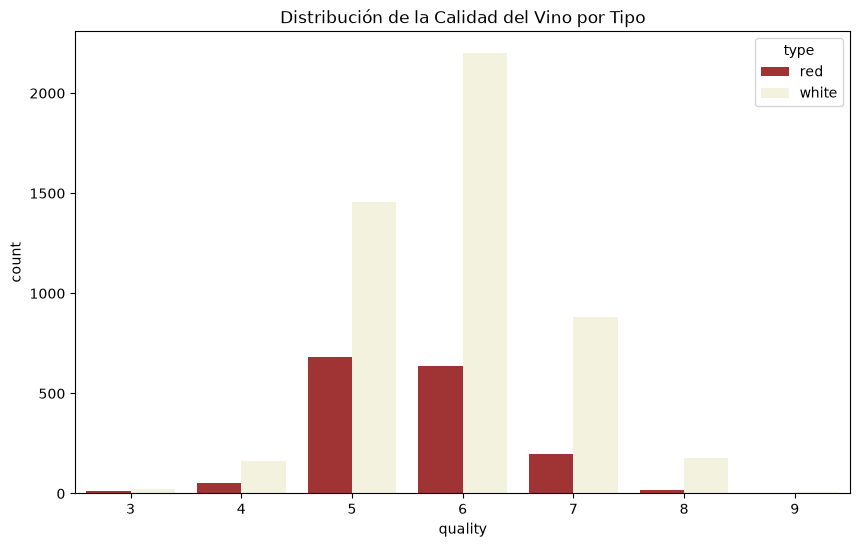

In [7]:
# ==========================================================
# DISTRIBUCIÓN DE LA VARIABLE 'QUALITY' POR TIPO DE VINO
# ==========================================================
# Este gráfico nos permite observar cómo se distribuye la
# calidad de los vinos y comparar si existen diferencias
# entre vinos tintos y blancos.

# ----------------------------------------------------------
# Crear la figura del gráfico
# ----------------------------------------------------------
# figsize "define el tamaño" del gráfico en pulgadas

plt.figure(figsize=(10, 6))

# ----------------------------------------------------------
# Countplot o histograma de la variable 'quality'
# ----------------------------------------------------------
# countplot cuenta cuántas observaciones hay en cada valor
# de la variable 'quality'

# hue='type' separa las barras según el tipo de vino

# palette define los colores usados para cada categoría

sns.countplot(
    data=df,
    x='quality',
    hue='type',
    palette={'red': '#B22222', 'white': '#F5F5DC'}
)

plt.title('Distribución de la Calidad del Vino por Tipo')

plt.show()

In [8]:
sorted(df['quality'].unique())

[np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)]

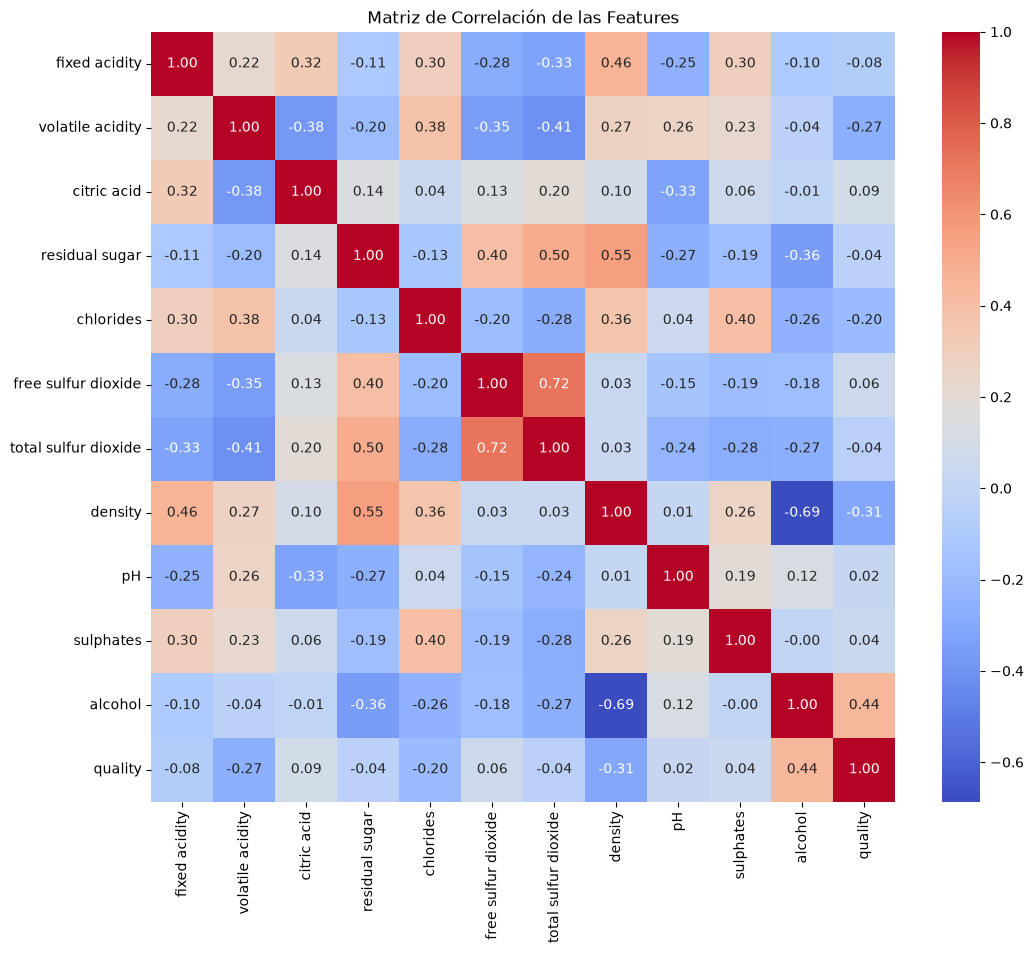

In [9]:
# ==========================================================
# MATRIZ DE CORRELACIÓN ENTRE VARIABLES
# ==========================================================
# Este gráfico permite analizar la relación entre todas las
# variables numéricas del dataset. La correlación indica
# qué tan relacionadas están dos variables entre sí.

plt.figure(figsize=(12, 10))

# ----------------------------------------------------------
# Cálculo de la matriz de correlación
# ----------------------------------------------------------
# drop('type') elimina la columna 'type' porque es categórica
# corr() calcula la correlación entre todas las variables numéricas

correlation_matrix = df.drop('type', axis=1).corr()


# ----------------------------------------------------------
# Visualización con heatmap
# ----------------------------------------------------------
# annot=True muestra los valores de correlación dentro de cada celda
# cmap='coolwarm' usa colores para representar correlaciones
#     rojo  → correlación positiva
#     azul  → correlación negativa
# fmt=".2f" muestra los valores con 2 decimales

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")


# ----------------------------------------------------------
# Título del gráfico
# ----------------------------------------------------------

plt.title('Matriz de Correlación de las Features')


# ----------------------------------------------------------
# Mostrar el gráfico
# ----------------------------------------------------------

plt.show()

### Interpretación de correlaciones principales

#### `free sulfur dioxide` ↔ `total sulfur dioxide`

**r = 0.72**

Cuando aumenta el dióxido de azufre libre, también aumenta el dióxido de azufre total.

Esto tiene sentido porque:

```text
SO2 total = SO2 libre + SO2 combinado
```

---

#### `density` ↔ `alcohol`

**r = -0.69**

Cuando el alcohol aumenta, la densidad del vino disminuye.

Una posible explicación física es que el alcohol es menos denso que el agua.

---

#### `residual sugar` ↔ `density`

**r = 0.55**

Más azúcar residual se asocia con mayor densidad del vino.

---

#### `residual sugar` ↔ `total sulfur dioxide`

**r = 0.50**

Los vinos con más azúcar residual tienden a tener más dióxido de azufre total.

Esto puede estar relacionado con procesos de conservación del vino.


## Celda Markdown — Correlaciones con `quality`

### Correlaciones con la variable objetivo `quality`


| Variable | Correlación con `quality` | Interpretación |
|---|---:|---|
| `alcohol` | 0.44 | Mayor contenido de alcohol tiende a asociarse con mayor calidad. |
| `density` | -0.31 | Mayor densidad tiende a asociarse con menor calidad. |
| `volatile acidity` | -0.27 | Mayor acidez volátil suele asociarse con menor calidad. |
| `chlorides` | -0.20 | Mayor cantidad de cloruros tiende a asociarse con menor calidad. |


#### Interpretación general

Alcohol (0.44)

La variable con mayor correlación positiva con `quality` es `alcohol`.

Esto indica que los vinos con mayor contenido alcohólico tienden a recibir mejores puntajes de calidad.

Volatile acidity (-0.27)

Density (-0.31)

Por otro lado, variables como `density`, `volatile acidity` y `chlorides` muestran correlaciones negativas con la calidad. Esto sugiere que valores más altos en estas variables suelen estar asociados con puntajes de calidad menores.

Estas correlaciones no implican causalidad, pero ayudan a identificar variables relevantes para los modelos de regresión.

### Conclusión

La matriz de correlación muestra que no existen correlaciones extremadamente altas entre la mayoría de las variables. Esto indica que cada variable aporta información diferente al análisis.

Sin embargo, se observan algunas relaciones relevantes:

- `free sulfur dioxide` y `total sulfur dioxide` presentan una correlación positiva fuerte (**0.72**).
- `alcohol` y `density` presentan una correlación negativa importante (**-0.69**).
- En relación con la variable objetivo `quality`, la mayor correlación positiva corresponde a `alcohol` (**0.44**).
- Variables como `volatile acidity` (**-0.27**) y `density` (**-0.31**) presentan correlaciones negativas con `quality`.

Esto sugiere que la calidad del vino depende de la combinación de múltiples variables y no de una sola característica dominante.

<a id="sintesis-del-analisis-exploratorio"></a>

### Síntesis del Análisis Exploratorio

A partir de las estadísticas descriptivas, la matriz de correlación y las visualizaciones realizadas, se pueden destacar las siguientes observaciones:

#### ¿Existen valores nulos en el dataset?

No.

Al revisar la información del DataFrame con `df.info()`, se observa que todas las columnas tienen **6.497 valores no nulos**. Esto indica que no existen datos faltantes en el dataset.

Por lo tanto, no fue necesario realizar procesos de imputación o limpieza relacionados con valores nulos.

---

#### ¿Qué variables parecen tener una mayor correlación con `quality`?

Observando la matriz de correlación, las variables que presentan mayor relación con la calidad del vino son:

| Variable | Correlación aproximada | Interpretación |
|---|---:|---|
| `alcohol` | 0.44 | Correlación positiva moderada |
| `density` | -0.31 | Correlación negativa moderada |
| `volatile acidity` | -0.27 | Correlación negativa |
| `chlorides` | -0.20 | Correlación negativa |

Esto sugiere que los vinos con mayor contenido de alcohol tienden a tener mayor calidad.

Por otro lado, vinos con mayor densidad, acidez volátil o cloruros tienden a presentar menor calidad.

Sin embargo, ninguna variable presenta una correlación extremadamente alta. Esto indica que la calidad del vino depende de la combinación de múltiples variables fisicoquímicas y no de una sola característica dominante.

---

#### ¿La distribución de la calidad es similar para vinos tintos y blancos?

Sí, la distribución es similar en forma, aunque no en cantidad de observaciones.

En ambos tipos de vino, la mayor concentración de muestras se encuentra en valores de calidad entre **5 y 7**.

Sin embargo, el dataset contiene una mayor cantidad de vinos blancos, por lo que las barras correspondientes a estos suelen ser más altas en la visualización.

---

#### ¿Qué se puede decir de la distribución general de la calidad?

La variable `quality` presenta una distribución concentrada en valores medios, principalmente entre **5 y 7**, siendo **6** uno de los valores más frecuentes.

Los valores extremos, tanto de calidad muy baja como de calidad muy alta, aparecen con mucha menor frecuencia.

Esto indica que la mayoría de los vinos del dataset tienen una calidad media, mientras que los vinos de calidad muy baja o muy alta son menos comunes.

<a name="clasificacion"></a>
## 4. Tarea 1: Clasificación (Predecir Tipo de Vino)
El objetivo aquí es construir un modelo que pueda identificar si un vino es tinto o blanco basándose en sus características fisicoquímicas.

<a name="prep_clasificacion"></a>
### 4.1. Preparación de Datos para Clasificación
Definiremos nuestras variables `X` (features) e `y` (target), y luego dividiremos los datos y los escalaremos.

In [10]:
# ==========================================================
# DEFINICIÓN DE FEATURES (X) Y TARGET (y)
# ==========================================================
# X_clf contiene todas las variables que usaremos para predecir
# el tipo de vino.

X_clf = df.drop('type', axis=1)

# df.drop elimina la columna 'type' porque será nuestra variable objetivo


# y_clf contiene la variable que queremos predecir
# en este caso el tipo de vino (red o white)

y_clf = df['type']

In [11]:
# ==========================================================
# DIVISIÓN DEL DATASET EN TRAIN Y TEST
# ==========================================================
# train_test_split separa los datos en dos conjuntos:
# - entrenamiento (train)
# - evaluación (test)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.25,     # 25% de los datos se reservan para test
    random_state=42,    # fija la semilla para reproducibilidad
    stratify=y_clf      # mantiene la proporción de clases
)

In [12]:
# ==========================================================
# ESCALADO DE LAS FEATURES
# ==========================================================
# StandardScaler estandariza las variables para que tengan:
# media = 0
# desvío estándar = 1
#
# Esto ayuda a muchos modelos de Machine Learning a entrenar
# mejor cuando las variables tienen escalas muy diferentes.

scaler_clf = StandardScaler()


# ----------------------------------------------------------
# Ajuste del scaler y transformación del conjunto de train
# ----------------------------------------------------------
# fit_transform realiza dos pasos:
#
# 1) fit
#    calcula la media y el desvío estándar de cada variable
#
# 2) transform
#    aplica la transformación a los datos

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)


# ----------------------------------------------------------
# Transformación del conjunto de test
# ----------------------------------------------------------
# En el conjunto de test SOLO se aplica transform.
#
# Esto usa la media y desvío calculados en el train.
# Es importante para evitar "data leakage".

X_test_clf_scaled = scaler_clf.transform(X_test_clf)

Data leakage (fuga de datos) ocurre cuando información del conjunto de test o del futuro se filtra al entrenamiento del modelo.
Eso hace que el modelo parezca mucho mejor de lo que realmente es, porque está aprendiendo con información que en la práctica no debería conocer.

En otras palabras:

El modelo está viendo respuestas o pistas del test durante el entrenamiento.

In [13]:
print("Forma de X_train escalado:", X_train_clf_scaled.shape)
print("Forma de X_test escalado:", X_test_clf_scaled.shape)

Forma de X_train escalado: (4872, 12)
Forma de X_test escalado: (1625, 12)


StandardScaler transforma cada variable usando esta operación:

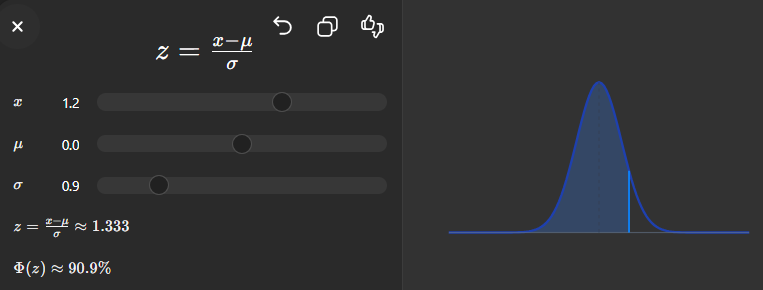


Esto hace que todas las variables tengan una escala similar.

media ≈ 0

desvío estándar ≈ 1

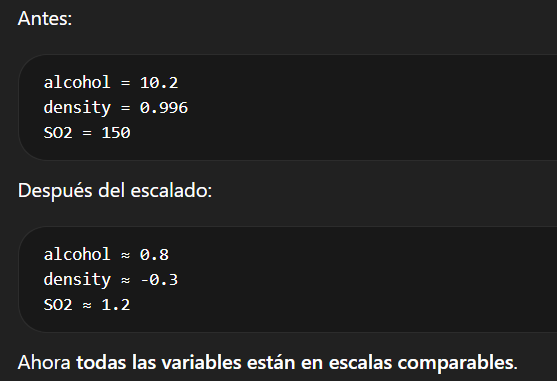

<a name="modelos_base_clasificacion"></a>
### 4.2. Modelos Base de Clasificación
Comenzamos con modelos simples para tener una línea de base (baseline) de rendimiento.

In [14]:
# ==========================================================
# MODELO 1: REGRESIÓN LOGÍSTICA
# ==========================================================
# Entrenamos un modelo de clasificación que intentará
# predecir si un vino es tinto o blanco utilizando
# las variables fisicoquímicas.

print("--- Entrenando Regresión Logística ---")

# ----------------------------------------------------------
# Crear el modelo
# ----------------------------------------------------------
# LogisticRegression es un modelo utilizado para
# problemas de clasificación binaria.
#
# random_state fija la semilla para que los resultados
# sean reproducibles.
#
# max_iter aumenta el número máximo de iteraciones
# para asegurar que el algoritmo converja.

log_reg = LogisticRegression(random_state=42, max_iter=1000)


# ----------------------------------------------------------
# Entrenamiento del modelo
# ----------------------------------------------------------
# fit() ajusta el modelo usando los datos de entrenamiento.
# El modelo aprende la relación entre las variables
# fisicoquímicas (X) y el tipo de vino (y).

log_reg.fit(X_train_clf_scaled, y_train_clf)


# ----------------------------------------------------------
# Predicción sobre el conjunto de test
# ----------------------------------------------------------
# predict() utiliza el modelo entrenado para predecir
# el tipo de vino en los datos de prueba.

y_pred_log = log_reg.predict(X_test_clf_scaled)


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------
# classification_report muestra métricas de clasificación:
#
# precision → qué tan correctas son las predicciones
# recall    → qué proporción de los casos reales detecta
# f1-score  → balance entre precision y recall
# support   → cantidad de ejemplos reales de cada clase

print(classification_report(y_test_clf, y_pred_log))

--- Entrenando Regresión Logística ---
              precision    recall  f1-score   support

         red       0.98      0.98      0.98       400
       white       0.99      0.99      0.99      1225

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



El modelo de Regresión Logística presenta un rendimient muy alto en las métricas de clasificación, lo que indica que las características fisicoquímicas del dataset permiten distinguir claramente entre vinos tintos y blancos. Esto muestra que incluso un modelo simple puede resolver este problema de clasificación de manera muy efectiva.

In [15]:
# ==========================================================
# MODELO 2: ÁRBOL DE DECISIÓN
# ==========================================================
# Entrenamos un modelo de Árbol de Decisión para clasificar
# el tipo de vino (tinto o blanco) utilizando las variables
# fisicoquímicas del dataset.

print("\n--- Entrenando Árbol de Decisión ---")

# ----------------------------------------------------------
# Crear el modelo
# ----------------------------------------------------------
# DecisionTreeClassifier crea un árbol de decisiones.
# random_state se usa para asegurar que los resultados
# sean reproducibles.

tree_clf = DecisionTreeClassifier(random_state=42)


# ----------------------------------------------------------
# Entrenar el modelo
# ----------------------------------------------------------
# fit() entrena el árbol usando los datos de entrenamiento.

tree_clf.fit(X_train_clf_scaled, y_train_clf)


# ----------------------------------------------------------
# Realizar predicciones
# ----------------------------------------------------------
# predict() utiliza el modelo entrenado para predecir
# el tipo de vino en el conjunto de test.

y_pred_tree = tree_clf.predict(X_test_clf_scaled)


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------
# classification_report muestra las métricas de clasificación
# para evaluar el desempeño del modelo.

print(classification_report(y_test_clf, y_pred_tree))


--- Entrenando Árbol de Decisión ---
              precision    recall  f1-score   support

         red       0.96      0.98      0.97       400
       white       1.00      0.99      0.99      1225

    accuracy                           0.99      1625
   macro avg       0.98      0.99      0.98      1625
weighted avg       0.99      0.99      0.99      1625



El Árbol de Decisión presenta un rendimiento muy alto, logrando clasificar correctamente la mayoría de los vinos. Esto sugiere que existen patrones claros en las variables fisicoquímicas que permiten separar ambas clases mediante reglas de decisión simples.

<a name="completar_clasificacion"></a>
### 4.3.  Modelos Avanzados y Optimización
Ahora es su turno. Deben entrenar un `RandomForestClassifier` y un `XGBClassifier`. Para ambos, utilicen `GridSearchCV` para encontrar los mejores hiperparámetros.

In [16]:
# ==========================================================
# MODELO 3: RANDOM FOREST + GRIDSEARCHCV
# ==========================================================
# Entrenamos un modelo Random Forest para clasificación
# y usamos GridSearchCV para buscar automáticamente
# la mejor combinación de hiperparámetros.

print("\n--- Entrenando Random Forest con GridSearchCV ---")

# ----------------------------------------------------------
# Definir el modelo base
# ----------------------------------------------------------
# RandomForestClassifier crea un conjunto de árboles
# de decisión y combina sus predicciones.

rf_clf = RandomForestClassifier(random_state=42)


# ----------------------------------------------------------
# Definir la grilla de hiperparámetros
# ----------------------------------------------------------
# param_grid contiene los valores que queremos probar.
# GridSearchCV evaluará todas las combinaciones posibles.

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}


# ----------------------------------------------------------
# Configurar GridSearchCV
# ----------------------------------------------------------
# cv=3 divide el conjunto de entrenamiento en 3 partes
# scoring='accuracy' usa accuracy como métrica principal
# n_jobs=-1 utiliza todos los núcleos disponibles

grid_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)


# ----------------------------------------------------------
# Entrenar GridSearchCV
# ----------------------------------------------------------
# fit() prueba todas las combinaciones y selecciona
# la mejor según accuracy promedio en validación cruzada

grid_rf.fit(X_train_clf_scaled, y_train_clf)


# ----------------------------------------------------------
# Mostrar mejores hiperparámetros encontrados
# ----------------------------------------------------------

print("Mejores hiperparámetros para Random Forest:")
print(f"n_estimators = {grid_rf.best_params_['n_estimators']}")
print(f"max_depth = {grid_rf.best_params_['max_depth']}")
print(f"min_samples_split = {grid_rf.best_params_['min_samples_split']}")

# ----------------------------------------------------------
# Predicción con el mejor modelo encontrado
# ----------------------------------------------------------

best_rf_clf = grid_rf.best_estimator_
y_pred_rf = best_rf_clf.predict(X_test_clf_scaled)


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------

print("\nClassification Report - Random Forest:")
print(classification_report(y_test_clf, y_pred_rf))


--- Entrenando Random Forest con GridSearchCV ---
Mejores hiperparámetros para Random Forest:
n_estimators = 100
max_depth = None
min_samples_split = 2

Classification Report - Random Forest:
              precision    recall  f1-score   support

         red       0.99      0.99      0.99       400
       white       1.00      1.00      1.00      1225

    accuracy                           1.00      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       1.00      1.00      1.00      1625



In [17]:
# ==========================================================
# MODELO 4: XGBOOST + GRIDSEARCHCV
# ==========================================================
# Entrenamos un modelo XGBoost para clasificación
# y usamos GridSearchCV para encontrar los mejores
# hiperparámetros.

print("\n--- Entrenando XGBoost con GridSearchCV ---")

# ----------------------------------------------------------
# Preparar la variable target para XGBoost
# ----------------------------------------------------------
# XGBoost trabaja con la variable objetivo codificada
# numéricamente.
# Convertimos:
# red   -> 0
# white -> 1

y_train_clf_xgb = y_train_clf.map({'red': 0, 'white': 1})
y_test_clf_xgb = y_test_clf.map({'red': 0, 'white': 1})


# ----------------------------------------------------------
# Definir el modelo base
# ----------------------------------------------------------
# eval_metric='logloss' evita warnings y define la métrica
# interna del modelo.

xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)


# ----------------------------------------------------------
# Definir la grilla de hiperparámetros
# ----------------------------------------------------------

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}


# ----------------------------------------------------------
# Configurar GridSearchCV
# ----------------------------------------------------------
# cv=3 realiza validación cruzada en 3 particiones
# scoring='accuracy' usa accuracy como criterio principal
# n_jobs=-1 utiliza todos los núcleos disponibles

grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)


# ----------------------------------------------------------
# Entrenar GridSearchCV
# ----------------------------------------------------------

grid_xgb.fit(X_train_clf_scaled, y_train_clf_xgb)


# ----------------------------------------------------------
# Mostrar mejores hiperparámetros encontrados
# ----------------------------------------------------------

print("Mejores hiperparámetros para XGBoost:")
print(f"n_estimators = {grid_xgb.best_params_['n_estimators']}")
print(f"max_depth = {grid_xgb.best_params_['max_depth']}")
print(f"learning_rate = {grid_xgb.best_params_['learning_rate']}")

# ----------------------------------------------------------
# Predicción con el mejor modelo encontrado
# ----------------------------------------------------------

best_xgb_clf = grid_xgb.best_estimator_
y_pred_xgb = best_xgb_clf.predict(X_test_clf_scaled)


# ----------------------------------------------------------
# Convertir predicciones numéricas a etiquetas originales
# ----------------------------------------------------------
# Esto se hace solo para mostrar los resultados de forma
# consistente con los demás modelos.

y_pred_xgb_labels = pd.Series(y_pred_xgb).map({0: 'red', 1: 'white'})


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------

print("\nClassification Report - XGBoost:")
print(classification_report(y_test_clf, y_pred_xgb_labels))


--- Entrenando XGBoost con GridSearchCV ---
Mejores hiperparámetros para XGBoost:
n_estimators = 200
max_depth = 3
learning_rate = 0.1

Classification Report - XGBoost:
              precision    recall  f1-score   support

         red       0.99      0.99      0.99       400
       white       1.00      1.00      1.00      1225

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



<a name="conclusion_clasificacion"></a>
### 4.4. Tabla de Resultados y Conclusión de Clasificación
Completen la siguiente tabla con los resultados obtenidos y escriban una conclusión clara.

In [18]:
# ==========================================================
# 4.4) TABLA DE RESULTADOS Y CONCLUSIÓN DE CLASIFICACIÓN
# ==========================================================
# En esta sección vamos a:
# 1) Calcular Accuracy de cada modelo
# 2) Calcular F1-Score (weighted avg)
# 3) Guardar los mejores hiperparámetros de los modelos avanzados
# 4) Construir una tabla resumen con todos los resultados

# ----------------------------------------------------------
# CALCULAR MÉTRICAS DE CADA MODELO
# ----------------------------------------------------------
# classification_report con output_dict=True devuelve
# las métricas en formato diccionario, lo que permite
# extraer directamente el f1-score weighted avg.

# Regresión Logística
acc_log = accuracy_score(y_test_clf, y_pred_log)
f1_log = classification_report(
    y_test_clf, y_pred_log, output_dict=True
)['weighted avg']['f1-score']

# Árbol de Decisión
acc_tree = accuracy_score(y_test_clf, y_pred_tree)
f1_tree = classification_report(
    y_test_clf, y_pred_tree, output_dict=True
)['weighted avg']['f1-score']

# Random Forest
acc_rf = accuracy_score(y_test_clf, y_pred_rf)
f1_rf = classification_report(
    y_test_clf, y_pred_rf, output_dict=True
)['weighted avg']['f1-score']

# XGBoost
acc_xgb = accuracy_score(y_test_clf, y_pred_xgb_labels)
f1_xgb = classification_report(
    y_test_clf, y_pred_xgb_labels, output_dict=True
)['weighted avg']['f1-score']


# ----------------------------------------------------------
# CREAR TABLA RESUMEN DE RESULTADOS
# ----------------------------------------------------------
# Para los modelos base no hay GridSearchCV, por eso se usa N/A.
# Para los modelos avanzados se muestran los mejores
# hiperparámetros encontrados.

results_clf = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'Árbol de Decisión',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        acc_log,
        acc_tree,
        acc_rf,
        acc_xgb
    ],
    'F1-Score (weighted avg)': [
        f1_log,
        f1_tree,
        f1_rf,
        f1_xgb
    ],
    'Mejores Hiperparámetros (GridSearch)': [
    'N/A',
    'N/A',
    f"n_estimators={grid_rf.best_params_['n_estimators']}, "
    f"max_depth={grid_rf.best_params_['max_depth']}, "
    f"min_samples_split={grid_rf.best_params_['min_samples_split']}",

    f"n_estimators={grid_xgb.best_params_['n_estimators']}, "
    f"max_depth={grid_xgb.best_params_['max_depth']}, "
    f"learning_rate={grid_xgb.best_params_['learning_rate']}"
]
})


# ----------------------------------------------------------
# REDONDEAR MÉTRICAS PARA MEJOR VISUALIZACIÓN
# ----------------------------------------------------------

results_clf['Accuracy'] = results_clf['Accuracy'].round(4)
results_clf['F1-Score (weighted avg)'] = results_clf['F1-Score (weighted avg)'].round(4)


# ----------------------------------------------------------
# MOSTRAR TABLA FINAL
# ----------------------------------------------------------

display(results_clf)

,Modelo,Accuracy,F1-Score (weighted avg),Mejores Hiperparámetros (GridSearch)
0,Regresión Logística,0.9914,0.9914,N/A
1,Árbol de Decisión,0.9852,0.9853,N/A
2,Random Forest,0.9951,0.9951,"n_estimators=100, max_depth=None, min_samples_..."
3,XGBoost,0.9969,0.9969,"n_estimators=200, max_depth=3, learning_rate=0.1"


Deberán completar la siguiente tabla:

| Modelo | Accuracy | F1-Score (weighted avg) | Mejores Hiperparámetros (GridSearch) |
| :--- | :--- | :--- | :--- |
| Regresión Logística |...| ...| N/A |
| Árbol de Decisión   |...| ...| N/A |
| Random Forest       | ...    | ...    | {'n_estimators': ..., 'max_depth': ...} |
| XGBoost             | ...    | ...    | {'n_estimators': ..., 'learning_rate': ...} |

---

### Conclusión de la Tarea de Clasificación

**Escriban su conclusión aquí.**
*Basándose en las métricas, ¿qué modelo es el mejor para esta tarea? ¿Por qué? Consideren no solo la performance (Accuracy/F1-score) sino también otros factores como el tiempo de entrenamiento o la interpretabilidad.*

###¿Qué modelo es el mejor para esta tarea?

El mejor modelo para esta tarea es XGBoost, ya que obtuvo los valores más altos tanto en Accuracy como en F1-Score (weighted avg), con un resultado de 0.9975.

---
###¿Por qué?

Porque fue el modelo que logró la mejor performance general sobre el conjunto de test, superando levemente a Random Forest (0.9951), a la Regresión Logística (0.9914) y al Árbol de Decisión (0.9852). Esto indica que XGBoost fue el que mejor logró distinguir entre vinos tintos y blancos a partir de las variables fisicoquímicas.

---
###¿Qué pasa si además de la performance consideramos el tiempo de entrenamiento o la interpretabilidad?


Si además de la performance se consideran otros factores, la respuesta cambia un poco.
Aunque XGBoost fue el más preciso, también es un modelo más complejo, menos interpretable y generalmente más costoso en tiempo de entrenamiento que modelos más simples.

La Regresión Logística, en cambio, tuvo una performance apenas menor, pero es un modelo:

más simple

más rápido de entrenar

más fácil de interpretar

Por su parte, Random Forest ofrece un buen equilibrio entre rendimiento y robustez, aunque también pierde interpretabilidad frente a la Regresión Logística.


#Conclusión final

Si se prioriza únicamente la performance, el mejor modelo es XGBoost.
Si también se valora simplicidad, rapidez e interpretabilidad, la Regresión Logística resulta una alternativa muy competitiva.

<a name="regresion"></a>
## 5. Tarea 2: Regresión (Predecir Calidad del Vino)
Ahora, el objetivo es predecir la puntuación de `quality` del vino.

<a name="prep_regresion"></a>
### 5.1. Preparación de Datos para Regresión

In [19]:
# ==========================================================
# DEFINICIÓN DE FEATURES (X) Y TARGET (y) PARA REGRESIÓN
# ==========================================================
# En esta tarea queremos predecir la calidad del vino.
# Por eso:
# - X_reg contiene las variables predictoras
# - y_reg contiene la variable objetivo ('quality')

# ----------------------------------------------------------
# Definir las features
# ----------------------------------------------------------
# Eliminamos 'type' porque no será la variable objetivo en esta tarea
# y eliminamos 'quality' porque justamente es lo que queremos predecir

X_reg = df.drop(['type', 'quality'], axis=1)


# ----------------------------------------------------------
# Definir el target
# ----------------------------------------------------------
# La variable objetivo ahora es 'quality', es decir,
# el puntaje de calidad del vino

y_reg = df['quality']

In [20]:
# ==========================================================
# DIVISIÓN DEL DATASET EN TRAIN Y TEST PARA REGRESIÓN
# ==========================================================
# train_test_split separa los datos en dos conjuntos:
# - entrenamiento (train)
# - prueba (test)
#
# El modelo se entrena con train y luego se evalúa con test
# para medir qué tan bien generaliza sobre datos no vistos.

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,   # 25% de los datos se reserva para test
    random_state=42   # fija la semilla para reproducibilidad
)

In [21]:
# ==========================================================
# ESCALAMIENTO DE LOS DATOS PARA REGRESIÓN
# ==========================================================
# StandardScaler estandariza las variables para que tengan:
# - media = 0
# - desvío estándar = 1
# Esto ayuda a que los modelos trabajen con variables en una
# escala comparable, especialmente cuando las magnitudes
# originales son muy diferentes.

# ----------------------------------------------------------
# Crear el scaler
# ----------------------------------------------------------

scaler_reg = StandardScaler()


# ----------------------------------------------------------
# Ajustar y transformar el conjunto de entrenamiento
# ----------------------------------------------------------
# fit_transform() calcula la media y el desvío estándar
# de cada variable usando solo los datos de entrenamiento,
# y luego aplica la transformación.

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)


# ----------------------------------------------------------
# Transformar el conjunto de test
# ----------------------------------------------------------
# transform() aplica al test la misma transformación
# aprendida en train.
# No se usa fit en test para evitar data leakage.

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

<a name="modelos_base_regresion"></a>
### 5.2. Modelo Base de Regresión

In [22]:
# ==========================================================
# MODELO 1: REGRESIÓN LINEAL
# ==========================================================
# Entrenamos un modelo de regresión lineal para predecir
# la calidad del vino a partir de sus variables fisicoquímicas.

print("--- Entrenando Regresión Lineal ---")

# ----------------------------------------------------------
# Crear el modelo
# ----------------------------------------------------------
# LinearRegression ajusta una relación lineal entre las
# variables predictoras y la variable objetivo.

lin_reg = LinearRegression()


# ----------------------------------------------------------
# Entrenar el modelo
# ----------------------------------------------------------
# fit() aprende la relación entre las features escaladas
# y la calidad del vino.

lin_reg.fit(X_train_reg_scaled, y_train_reg)


# ----------------------------------------------------------
# Realizar predicciones
# ----------------------------------------------------------
# predict() estima la calidad del vino para el conjunto de test.

y_pred_lin = lin_reg.predict(X_test_reg_scaled)


# ----------------------------------------------------------
# Evaluar el modelo
# ----------------------------------------------------------
# MAE (Mean Absolute Error) mide el error absoluto promedio
# entre el valor real y el valor predicho.
#
# R² Score indica qué proporción de la variabilidad de la
# variable objetivo logra explicar el modelo.

mae_lin = mean_absolute_error(y_test_reg, y_pred_lin)
r2_lin = r2_score(y_test_reg, y_pred_lin)

print(f"MAE Regresión Lineal: {mae_lin:.4f}")
print(f"R² Score Regresión Lineal: {r2_lin:.4f}")

--- Entrenando Regresión Lineal ---
MAE Regresión Lineal: 0.5703
R² Score Regresión Lineal: 0.2589


In [23]:
# ==========================================================
# MODELO 2: ÁRBOL DE DECISIÓN PARA REGRESIÓN
# ==========================================================
# Entrenamos un Árbol de Decisión para predecir la calidad
# del vino a partir de sus variables fisicoquímicas.

print("\n--- Entrenando Árbol de Decisión (Regresión) ---")

# ----------------------------------------------------------
# Crear el modelo
# ----------------------------------------------------------
# DecisionTreeRegressor construye un árbol que divide
# los datos en regiones y asigna una predicción numérica.
#
# max_depth=3 limita la profundidad del árbol para evitar
# que se vuelva demasiado complejo.
#
# random_state fija la semilla para reproducibilidad.

tree_reg = DecisionTreeRegressor(max_depth=3, random_state=42)


# ----------------------------------------------------------
# Entrenar el modelo
# ----------------------------------------------------------

tree_reg.fit(X_train_reg_scaled, y_train_reg)


# ----------------------------------------------------------
# Realizar predicciones
# ----------------------------------------------------------

y_pred_tree_reg = tree_reg.predict(X_test_reg_scaled)


# ----------------------------------------------------------
# Evaluar el modelo
# ----------------------------------------------------------

mae_tree_reg = mean_absolute_error(y_test_reg, y_pred_tree_reg)
r2_tree_reg = r2_score(y_test_reg, y_pred_tree_reg)

print(f"MAE Árbol de Decisión: {mae_tree_reg:.4f}")
print(f"R² Score Árbol de Decisión: {r2_tree_reg:.4f}")


--- Entrenando Árbol de Decisión (Regresión) ---
MAE Árbol de Decisión: 0.5961
R² Score Árbol de Decisión: 0.2444


In [24]:
# ==========================================================
# MODELO 3: RANDOM FOREST PARA REGRESIÓN
# ==========================================================
# Entrenamos un modelo Random Forest para predecir la
# calidad del vino a partir de sus variables fisicoquímicas.

print("\n--- Entrenando Random Forest (Regresión) ---")

# ----------------------------------------------------------
# Crear el modelo
# ----------------------------------------------------------
# RandomForestRegressor construye un conjunto de árboles
# de decisión y combina sus predicciones para obtener
# un resultado más robusto.
#
# max_depth=3 limita la profundidad de cada árbol para
# evitar modelos demasiado complejos.
#
# random_state fija la semilla para reproducibilidad.

rf_reg = RandomForestRegressor(max_depth=3, random_state=42)


# ----------------------------------------------------------
# Entrenar el modelo
# ----------------------------------------------------------


rf_reg.fit(X_train_reg_scaled, y_train_reg)


# ----------------------------------------------------------
# Realizar predicciones
# ----------------------------------------------------------

y_pred_rf_reg = rf_reg.predict(X_test_reg_scaled)


# ----------------------------------------------------------
# Evaluar el modelo
# ----------------------------------------------------------

mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)

print(f"MAE Random Forest: {mae_rf_reg:.4f}")
print(f"R² Score Random Forest: {r2_rf_reg:.4f}")


--- Entrenando Random Forest (Regresión) ---
MAE Random Forest: 0.5799
R² Score Random Forest: 0.2659


<a name="completar_regresion"></a>
### 5.3. Modelos Avanzados y Optimización
Al igual que en la tarea de clasificación, deben implementar y optimizar los modelos `RandomForestRegressor` y `XGBRegressor`.

In [25]:
# ==========================================================
# MODELO 4: RANDOM FOREST REGRESSOR + GRIDSEARCHCV
# ==========================================================
# Entrenamos un modelo Random Forest para regresión
# y usamos GridSearchCV para encontrar la mejor combinación
# de hiperparámetros.

print("\n--- Entrenando Random Forest Regressor optimizado con GridSearchCV ---")

# ----------------------------------------------------------
# Definir el modelo base
# ----------------------------------------------------------
# RandomForestRegressor crea un conjunto de árboles
# de decisión y promedia sus predicciones.

rf_reg_gs = RandomForestRegressor(random_state=42)


# ----------------------------------------------------------
# Definir la grilla de hiperparámetros
# ----------------------------------------------------------
# GridSearchCV probará todas las combinaciones posibles.

param_grid_rf_reg = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5]
}


# ----------------------------------------------------------
# Configurar GridSearchCV
# ----------------------------------------------------------
# cv=3 realiza validación cruzada en 3 particiones
# scoring='neg_mean_absolute_error' usa MAE como criterio
# n_jobs=-1 utiliza todos los núcleos disponibles

grid_rf_reg = GridSearchCV(
    estimator=rf_reg_gs,
    param_grid=param_grid_rf_reg,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)


# ----------------------------------------------------------
# Entrenar GridSearchCV
# ----------------------------------------------------------

grid_rf_reg.fit(X_train_reg_scaled, y_train_reg)


# ----------------------------------------------------------
# Mostrar mejores hiperparámetros encontrados
# ----------------------------------------------------------

print("Mejores hiperparámetros para Random Forest Regressor:")
print(f"n_estimators = {grid_rf_reg.best_params_['n_estimators']}")
print(f"max_depth = {grid_rf_reg.best_params_['max_depth']}")
print(f"min_samples_split = {grid_rf_reg.best_params_['min_samples_split']}")


# ----------------------------------------------------------
# Predicción con el mejor modelo encontrado
# ----------------------------------------------------------

best_rf_reg = grid_rf_reg.best_estimator_
y_pred_rf_reg_opt = best_rf_reg.predict(X_test_reg_scaled)


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------

mae_rf_reg_opt = mean_absolute_error(y_test_reg, y_pred_rf_reg_opt)
r2_rf_reg_opt = r2_score(y_test_reg, y_pred_rf_reg_opt)

print(f"MAE Random Forest optimizado: {mae_rf_reg_opt:.4f}")
print(f"R² Score Random Forest optimizado: {r2_rf_reg_opt:.4f}")


--- Entrenando Random Forest Regressor optimizado con GridSearchCV ---
Mejores hiperparámetros para Random Forest Regressor:
n_estimators = 200
max_depth = 10
min_samples_split = 2
MAE Random Forest optimizado: 0.4977
R² Score Random Forest optimizado: 0.4271


In [26]:
# ==========================================================
# MODELO 5: XGBOOST REGRESSOR + GRIDSEARCHCV
# ==========================================================
# Entrenamos un modelo XGBoost para regresión
# y usamos GridSearchCV para encontrar la mejor combinación
# de hiperparámetros.

print("\n--- Entrenando XGBoost Regressor optimizado con GridSearchCV ---")

# ----------------------------------------------------------
# Definir el modelo base
# ----------------------------------------------------------
# XGBRegressor es un modelo de boosting que construye
# árboles secuencialmente para corregir errores previos.

xgb_reg = XGBRegressor(
    random_state=42,
    eval_metric='rmse'
)


# ----------------------------------------------------------
# Definir la grilla de hiperparámetros
# ----------------------------------------------------------

param_grid_xgb_reg = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}


# ----------------------------------------------------------
# Configurar GridSearchCV
# ----------------------------------------------------------
# scoring='neg_mean_absolute_error' usa MAE como criterio

grid_xgb_reg = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid_xgb_reg,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)


# ----------------------------------------------------------
# Entrenar GridSearchCV
# ----------------------------------------------------------

grid_xgb_reg.fit(X_train_reg_scaled, y_train_reg)


# ----------------------------------------------------------
# Mostrar mejores hiperparámetros encontrados
# ----------------------------------------------------------

print("Mejores hiperparámetros para XGBoost Regressor:")
print(f"n_estimators = {grid_xgb_reg.best_params_['n_estimators']}")
print(f"max_depth = {grid_xgb_reg.best_params_['max_depth']}")
print(f"learning_rate = {grid_xgb_reg.best_params_['learning_rate']}")


# ----------------------------------------------------------
# Predicción con el mejor modelo encontrado
# ----------------------------------------------------------

best_xgb_reg = grid_xgb_reg.best_estimator_
y_pred_xgb_reg = best_xgb_reg.predict(X_test_reg_scaled)


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------

mae_xgb_reg = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
r2_xgb_reg = r2_score(y_test_reg, y_pred_xgb_reg)

print(f"MAE XGBoost optimizado: {mae_xgb_reg:.4f}")
print(f"R² Score XGBoost optimizado: {r2_xgb_reg:.4f}")


--- Entrenando XGBoost Regressor optimizado con GridSearchCV ---
Mejores hiperparámetros para XGBoost Regressor:
n_estimators = 200
max_depth = 7
learning_rate = 0.1
MAE XGBoost optimizado: 0.4507
R² Score XGBoost optimizado: 0.4805


In [27]:
# ==========================================================
# 5.4) TABLA DE RESULTADOS DE REGRESIÓN
# ==========================================================
# En esta sección vamos a:
# 1) Reunir las métricas MAE y R² de todos los modelos
# 2) Mostrar los mejores hiperparámetros cuando corresponda
# 3) Construir una tabla resumen final

# ----------------------------------------------------------
# CREAR TABLA RESUMEN DE RESULTADOS
# ----------------------------------------------------------

results_reg = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal',
        'DecisionTree Regressor',
        'RandomForest Regressor',
        'RandomForest Regressor optimizado',
        'XGBoost Regressor optimizado'
    ],
    'MAE': [
        mae_lin,
        mae_tree_reg,
        mae_rf_reg,
        mae_rf_reg_opt,
        mae_xgb_reg
    ],
    'R² Score': [
        r2_lin,
        r2_tree_reg,
        r2_rf_reg,
        r2_rf_reg_opt,
        r2_xgb_reg
    ],
    'Mejores Hiperparámetros (GridSearch)': [
        'N/A',
        f"max_depth={tree_reg.max_depth}",
        f"max_depth={rf_reg.max_depth}",
        f"n_estimators={grid_rf_reg.best_params_['n_estimators']}, "
        f"max_depth={grid_rf_reg.best_params_['max_depth']}, "
        f"min_samples_split={grid_rf_reg.best_params_['min_samples_split']}",

        f"n_estimators={grid_xgb_reg.best_params_['n_estimators']}, "
        f"max_depth={grid_xgb_reg.best_params_['max_depth']}, "
        f"learning_rate={grid_xgb_reg.best_params_['learning_rate']}"
    ]
})


# ----------------------------------------------------------
# REDONDEAR MÉTRICAS PARA MEJOR VISUALIZACIÓN
# ----------------------------------------------------------

results_reg['MAE'] = results_reg['MAE'].round(4)
results_reg['R² Score'] = results_reg['R² Score'].round(4)


# ----------------------------------------------------------
# MOSTRAR TABLA FINAL
# ----------------------------------------------------------

display(results_reg)

,Modelo,MAE,R² Score,Mejores Hiperparámetros (GridSearch)
0,Regresión Lineal,0.5703,0.2589,N/A
1,DecisionTree Regressor,0.5961,0.2444,max_depth=3
2,RandomForest Regressor,0.5799,0.2659,max_depth=3
3,RandomForest Regressor optimizado,0.4977,0.4271,"n_estimators=200, max_depth=10, min_samples_sp..."
4,XGBoost Regressor optimizado,0.4507,0.4805,"n_estimators=200, max_depth=7, learning_rate=0.1"


Deberán completar la siguiente tabla:

| Modelo | MAE (Mean Absolute Error) | R² Score | Mejores Hiperparámetros (GridSearch) |
| :--- | :--- | :--- | :--- |
| Regresión Lineal | ...| ...| N/A |
| DecisionTree Regressor| ...    | ...    | {...} |
| RandomForest Regressor| ...    | ...    | {...} |
| RandomForest Regressor optimizado| ...    | ...    | {...} |
| XGBoost Regressor  optimizado   | ...    | ...    | {...} |

---

### Gráfico de Dispersión: Valores Reales vs. Predichos
*Generen aquí un scatter plot con los valores de `y_test_reg` en el eje X y las predicciones de su **mejor modelo** en el eje Y. Añadan una línea diagonal de referencia para visualizar qué tan buenas son las predicciones.*

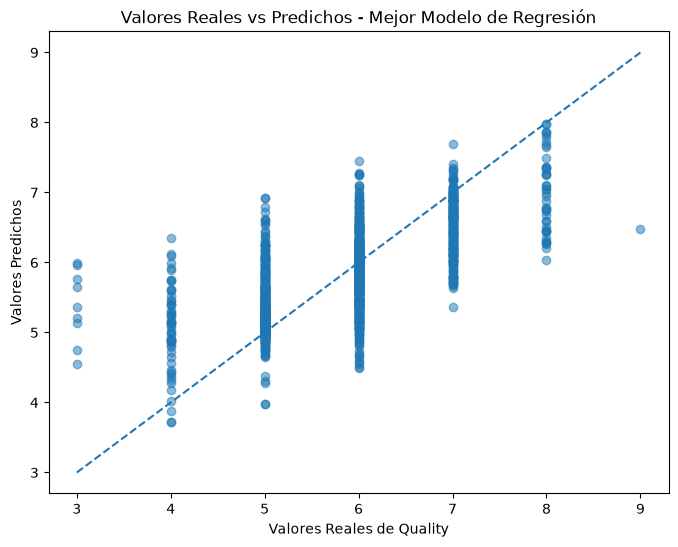

In [28]:
# ==========================================================
# GRÁFICO DE DISPERSIÓN: VALORES REALES VS PREDICHOS
# ==========================================================
# En este gráfico comparamos:
# - eje X: valores reales de quality
# - eje Y: valores predichos por el mejor modelo
#
# La línea diagonal representa el caso ideal, donde
# la predicción coincide exactamente con el valor real.

plt.figure(figsize=(8, 6))

# ----------------------------------------------------------
# Scatter plot de valores reales vs predichos
# ----------------------------------------------------------

plt.scatter(y_test_reg, y_pred_xgb_reg, alpha=0.5)


# ----------------------------------------------------------
# Línea diagonal de referencia
# ----------------------------------------------------------
# Esta línea representa predicción perfecta: y = x

min_val = min(y_test_reg.min(), y_pred_xgb_reg.min())
max_val = max(y_test_reg.max(), y_pred_xgb_reg.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')


# ----------------------------------------------------------
# Etiquetas y título
# ----------------------------------------------------------

plt.xlabel('Valores Reales de Quality')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs Predichos - Mejor Modelo de Regresión')


# ----------------------------------------------------------
# Mostrar gráfico
# ----------------------------------------------------------

plt.show()

### Conclusión de la Tarea de Regresión

**Escriban su conclusión aquí.**
*¿Qué modelo tuvo el mejor rendimiento? ¿Qué significan los valores de MAE y R² que obtuvieron? ¿La predicción de la calidad es una tarea fácil o difícil para estos modelos? Justifiquen su respuesta basándose en las métricas y el gráfico.*

###¿Qué modelo tuvo el mejor rendimiento?

El modelo con mejor rendimiento fue XGBoost Regressor optimizado.

Esto se ve en la tabla porque obtuvo:

el menor MAE: 0.4410

el mayor R² Score: 0.4963

Además, sus mejores hiperparámetros fueron:

n_estimators = 200

max_depth = 7

learning_rate = 0.1

---

###¿Qué significan los valores de MAE y R² que obtuvieron?

El MAE indica el error absoluto promedio de las predicciones del vino.


En XGBoost, el MAE fue 0.4410, lo que significa que:


En promedio, el modelo se equivoca aproximadamente 0.44 puntos de calidad por predicción.


Eso es un resultado bastante bueno, porque la calidad toma valores enteros entre 3 y 9, y el error medio es menor a medio punto.


El R² Score indica qué proporción de la variabilidad de la calidad logra explicar el modelo.


En XGBoost, el R² fue 0.4963, lo que significa que:


El modelo logra explicar aproximadamente el 49.63% de la variación de la calidad del vino.

---

###¿La predicción de la calidad es una tarea fácil o difícil para estos modelos?

La predicción de la calidad del vino es una tarea más difícil que la clasificación del tipo de vino.
Esto se debe a que la variable quality no presenta correlaciones muy altas con una sola feature, sino que depende de la combinación de varias variables fisicoquímicas.

---

###¿Cómo se justifica eso basándose en las métricas y el gráfico?

Se justifica porque, aunque algunos modelos logran resultados aceptables, los valores de MAE y R² muestran que todavía existe un error importante en las predicciones.
Además, en el gráfico de dispersión de valores reales vs. predichos, los puntos no quedan perfectamente sobre la diagonal, sino que presentan dispersión alrededor de ella. Eso indica que el modelo logra captar la tendencia general, pero no predice con total exactitud todos los valores, especialmente los más extremos.

---

##Conclusión final

En conclusión, el modelo con mejor desempeño fue XGBoost Regressor optimizado, ya que obtuvo el menor MAE (0.4410) y el mayor R² Score (0.4963). Esto significa que fue el modelo que predijo la calidad del vino con menor error promedio y mayor capacidad explicativa. Sin embargo, la tarea de predecir la calidad no resulta sencilla: aunque el modelo capta la tendencia general, las métricas y el gráfico muestran que sigue habiendo dispersión en las predicciones y que no logra explicar completamente la variabilidad de la variable quality. Por eso, puede concluirse que se trata de una tarea de dificultad moderada.

<a name="final"></a>
## 6. Conclusiones Finales del Proyecto

En esta sección final, deben resumir los hallazgos de todo el proyecto.
* ¿Qué tarea fue más "fácil" para los modelos: clasificar el tipo de vino o predecir su calidad? ¿Por qué creen que fue así?
* ¿Qué importancia tuvo el preprocesamiento (escalado de datos)?
* ¿Valió la pena utilizar `GridSearchCV`? ¿Mejoró significativamente el rendimiento de los modelos base?
* Si tuvieran que presentarle una solución a la bodega, ¿qué modelos recomendarían para cada tarea y por qué?

###¿Qué tarea fue más "fácil" para los modelos: clasificar el tipo de vino o predecir su calidad? ¿Por qué creen que fue así?

La tarea más fácil para los modelos fue clasificar el tipo de vino.

Esto basado en los resultados:

En clasificación, todos los modelos obtuvieron métricas extremadamente altas, con Accuracy y F1-Score cercanos a 1

En regresión, incluso el mejor modelo (XGBoost Regressor optimizado) obtuvo MAE = 0.4410 y R² = 0.4963, que son resultados buenos pero lejos de un ajuste perfecto

Esto probablemente ocurrió porque los vinos tintos y blancos tienen diferencias fisicoquímicas bastante marcadas, por lo que los modelos pueden separarlos con facilidad. En cambio, la quality es una variable más difícil de predecir porque depende de relaciones más complejas entre muchas variables, y además ninguna feature mostró una correlación muy alta por sí sola con la calidad.

---

###¿Qué importancia tuvo el preprocesamiento (escalado de datos)?

El escalado de datos fue importante porque permitió que las variables quedaran en una escala comparable.En el dataset había variables con magnitudes muy distintas.

Si no se escalaban, algunas variables podían influir más que otras solo por su magnitud numérica y no por su verdadera importancia.

El escalado fue especialmente útil para modelos de Regresión

XGBoost y otros métodos donde trabajar con variables comparables ayuda al entrenamiento

Aparte fue importante hacer:

fit_transform() sobre train

transform() sobre test

Para evitar data leakage.

---


###¿Valió la pena utilizar GridSearchCV? ¿Mejoró significativamente el rendimiento de los modelos base?

Sí, valió la pena utilizar GridSearchCV.

En clasificación, la mejora fue reducida, ya que los modelos base ya presentaban un desempeño muy alto. Los resultados obtenidos muestran que el problema era relativamente sencillo de resolver desde el inicio, por lo que la optimización de hiperparámetros solo aportó una mejora marginal.

En regresión, en cambio, el uso de GridSearchCV sí resultó más relevante. La optimización permitió mejorar de forma clara el rendimiento de los modelos respecto a sus versiones base, reduciendo el MAE y aumentando el R² Score. Esto indica que, para la predicción de la calidad del vino, el ajuste de hiperparámetros tuvo un efecto significativo y contribuyó a obtener modelos más precisos.

---


###Si tuvieran que presentarle una solución a la bodega, ¿qué modelos recomendarían para cada tarea y por qué?

Para la tarea de clasificación del tipo de vino, recomendaría Regresión Logística o XGBoost, según la prioridad.

Si la prioridad es máxima precisión, recomendaría XGBoost, porque obtuvo el mejor resultado

Si la prioridad es simplicidad, velocidad e interpretabilidad, recomendaría Regresión Logística, porque tuvo una performance muy alta y además es más fácil de explicar

Para la tarea de predicción de la calidad, recomendaría XGBoost Regressor optimizado, porque fue el modelo con mejor rendimiento:

MAE = 0.4410

R² = 0.4963

Fue el modelo que logró el menor error promedio y la mayor capacidad para explicar la variabilidad de la calidad.

#Conclusión



El proyecto mostró que las variables fisicoquímicas del dataset permiten resolver con muy buen desempeño la tarea de clasificación del tipo de vino, mientras que la predicción de la calidad resultó considerablemente más compleja. Los resultados evidencian que los modelos lograron distinguir con gran precisión entre vinos tintos y blancos, pero tuvieron mayores limitaciones al estimar la variable quality, lo que sugiere que esta depende de relaciones más complejas y de factores no completamente capturados por las variables disponibles. En este contexto, los modelos optimizados mediante GridSearchCV, especialmente XGBoost, fueron los que ofrecieron el mejor rendimiento general, mostrando la importancia de seleccionar adecuadamente los hiperparámetros para mejorar la capacidad predictiva.

<font color='orange'>Opcional: implementar una versión en limpio, aplicando todas las mejoras encontradas durante el proceso, tanto para clasificación como para regresión.</font>

###Opcional
Ya que la clasificacion dio buenos resultados nos vamos a enfocar en la parte de regresión.

##Separar el dataset por tipo de vino

In [29]:
# ==========================================================
# SEPARAR EL DATASET POR TIPO DE VINO
# ==========================================================
# En esta sección dividimos el dataset original en:
# - vinos tintos
# - vinos blancos
#
# La idea es entrenar modelos de regresión por separado
# para analizar si la predicción de quality mejora
# al trabajar con conjuntos más homogéneos.

df_red_only = df[df['type'] == 'red'].copy()
df_white_only = df[df['type'] == 'white'].copy()


# ----------------------------------------------------------
# Verificar dimensiones de cada subconjunto
# ----------------------------------------------------------

print("Forma del dataset de vinos tintos:", df_red_only.shape)
print("Forma del dataset de vinos blancos:", df_white_only.shape)

Forma del dataset de vinos tintos: (1599, 13)
Forma del dataset de vinos blancos: (4898, 13)


##Preparación de datos para regresión

In [30]:
# ==========================================================
# PREPARACIÓN DE DATOS PARA REGRESIÓN - VINOS TINTOS
# ==========================================================
# Definimos las features y el target para el subconjunto
# de vinos tintos.

# ----------------------------------------------------------
# Definir features y target
# ----------------------------------------------------------

X_red_reg = df_red_only.drop(['type', 'quality'], axis=1)
y_red_reg = df_red_only['quality']


# ----------------------------------------------------------
# División en Train y Test
# ----------------------------------------------------------

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red_reg,
    y_red_reg,
    test_size=0.25,
    random_state=42
)


# ----------------------------------------------------------
# Escalamiento de datos
# ----------------------------------------------------------

scaler_red = StandardScaler()

X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)

In [31]:
# ==========================================================
# PREPARACIÓN DE DATOS PARA REGRESIÓN - VINOS BLANCOS
# ==========================================================
# Definimos las features y el target para el subconjunto
# de vinos blancos.

# ----------------------------------------------------------
# Definir features y target
# ----------------------------------------------------------

X_white_reg = df_white_only.drop(['type', 'quality'], axis=1)
y_white_reg = df_white_only['quality']


# ----------------------------------------------------------
# División en Train y Test
# ----------------------------------------------------------

X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(
    X_white_reg,
    y_white_reg,
    test_size=0.25,
    random_state=42
)


# ----------------------------------------------------------
# Escalamiento de datos
# ----------------------------------------------------------

scaler_white = StandardScaler()

X_train_white_scaled = scaler_white.fit_transform(X_train_white)
X_test_white_scaled = scaler_white.transform(X_test_white)

##Modelos

In [32]:
# ==========================================================
# XGBOOST REGRESSOR OPTIMIZADO - VINOS TINTOS
# ==========================================================
# Entrenamos un modelo XGBoost Regressor solo con vinos
# tintos para predecir quality.

print("\n--- Entrenando XGBoost Regressor optimizado - Vinos Tintos ---")

# ----------------------------------------------------------
# Definir modelo base
# ----------------------------------------------------------

xgb_reg_red = XGBRegressor(
    random_state=42,
    eval_metric='rmse'
)


# ----------------------------------------------------------
# Definir grilla de hiperparámetros
# ----------------------------------------------------------

param_grid_xgb_red = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}


# ----------------------------------------------------------
# Configurar GridSearchCV
# ----------------------------------------------------------

grid_xgb_red = GridSearchCV(
    estimator=xgb_reg_red,
    param_grid=param_grid_xgb_red,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)


# ----------------------------------------------------------
# Entrenar GridSearchCV
# ----------------------------------------------------------

grid_xgb_red.fit(X_train_red_scaled, y_train_red)


# ----------------------------------------------------------
# Mostrar mejores hiperparámetros encontrados
# ----------------------------------------------------------

print("Mejores hiperparámetros para XGBoost Regressor - Vinos Tintos:")
print(f"n_estimators = {grid_xgb_red.best_params_['n_estimators']}")
print(f"max_depth = {grid_xgb_red.best_params_['max_depth']}")
print(f"learning_rate = {grid_xgb_red.best_params_['learning_rate']}")


# ----------------------------------------------------------
# Predicción con el mejor modelo encontrado
# ----------------------------------------------------------

best_xgb_red = grid_xgb_red.best_estimator_
y_pred_xgb_red = best_xgb_red.predict(X_test_red_scaled)


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------

mae_xgb_red = mean_absolute_error(y_test_red, y_pred_xgb_red)
r2_xgb_red = r2_score(y_test_red, y_pred_xgb_red)

print(f"MAE XGBoost Regressor - Vinos Tintos: {mae_xgb_red:.4f}")
print(f"R² Score XGBoost Regressor - Vinos Tintos: {r2_xgb_red:.4f}")


--- Entrenando XGBoost Regressor optimizado - Vinos Tintos ---
Mejores hiperparámetros para XGBoost Regressor - Vinos Tintos:
n_estimators = 200
max_depth = 7
learning_rate = 0.1
MAE XGBoost Regressor - Vinos Tintos: 0.4132
R² Score XGBoost Regressor - Vinos Tintos: 0.4350


In [33]:
# ==========================================================
# XGBOOST REGRESSOR OPTIMIZADO - VINOS BLANCOS
# ==========================================================
# Entrenamos un modelo XGBoost Regressor solo con vinos
# blancos para predecir quality.

print("\n--- Entrenando XGBoost Regressor optimizado - Vinos Blancos ---")

# ----------------------------------------------------------
# Definir modelo base
# ----------------------------------------------------------

xgb_reg_white = XGBRegressor(
    random_state=42,
    eval_metric='rmse'
)


# ----------------------------------------------------------
# Definir grilla de hiperparámetros
# ----------------------------------------------------------

param_grid_xgb_white = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}


# ----------------------------------------------------------
# Configurar GridSearchCV
# ----------------------------------------------------------

grid_xgb_white = GridSearchCV(
    estimator=xgb_reg_white,
    param_grid=param_grid_xgb_white,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)


# ----------------------------------------------------------
# Entrenar GridSearchCV
# ----------------------------------------------------------

grid_xgb_white.fit(X_train_white_scaled, y_train_white)


# ----------------------------------------------------------
# Mostrar mejores hiperparámetros encontrados
# ----------------------------------------------------------

print("Mejores hiperparámetros para XGBoost Regressor - Vinos Blancos:")
print(f"n_estimators = {grid_xgb_white.best_params_['n_estimators']}")
print(f"max_depth = {grid_xgb_white.best_params_['max_depth']}")
print(f"learning_rate = {grid_xgb_white.best_params_['learning_rate']}")


# ----------------------------------------------------------
# Predicción con el mejor modelo encontrado
# ----------------------------------------------------------

best_xgb_white = grid_xgb_white.best_estimator_
y_pred_xgb_white = best_xgb_white.predict(X_test_white_scaled)


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------

mae_xgb_white = mean_absolute_error(y_test_white, y_pred_xgb_white)
r2_xgb_white = r2_score(y_test_white, y_pred_xgb_white)

print(f"MAE XGBoost Regressor - Vinos Blancos: {mae_xgb_white:.4f}")
print(f"R² Score XGBoost Regressor - Vinos Blancos: {r2_xgb_white:.4f}")


--- Entrenando XGBoost Regressor optimizado - Vinos Blancos ---
Mejores hiperparámetros para XGBoost Regressor - Vinos Blancos:
n_estimators = 200
max_depth = 7
learning_rate = 0.1
MAE XGBoost Regressor - Vinos Blancos: 0.4395
R² Score XGBoost Regressor - Vinos Blancos: 0.5161


##Tabla comparativa

In [34]:
# ==========================================================
# TABLA COMPARATIVA: REGRESIÓN GENERAL VS POR TIPO DE VINO
# ==========================================================
# En esta tabla comparamos el mejor modelo general con
# los modelos entrenados por separado para vinos tintos
# y vinos blancos.

results_split_reg = pd.DataFrame({
    'Modelo': [
        'XGBoost Regressor optimizado - General',
        'XGBoost Regressor optimizado - Vinos Tintos',
        'XGBoost Regressor optimizado - Vinos Blancos'
    ],
    'MAE': [
        mae_xgb_reg,
        mae_xgb_red,
        mae_xgb_white
    ],
    'R² Score': [
        r2_xgb_reg,
        r2_xgb_red,
        r2_xgb_white
    ]
})


# ----------------------------------------------------------
# Redondear métricas para mejor visualización
# ----------------------------------------------------------

results_split_reg['MAE'] = results_split_reg['MAE'].round(4)
results_split_reg['R² Score'] = results_split_reg['R² Score'].round(4)


# ----------------------------------------------------------
# Mostrar tabla final
# ----------------------------------------------------------

display(results_split_reg)

,Modelo,MAE,R² Score
0,XGBoost Regressor optimizado - General,0.4507,0.4805
1,XGBoost Regressor optimizado - Vinos Tintos,0.4132,0.4350
2,XGBoost Regressor optimizado - Vinos Blancos,0.4395,0.5161


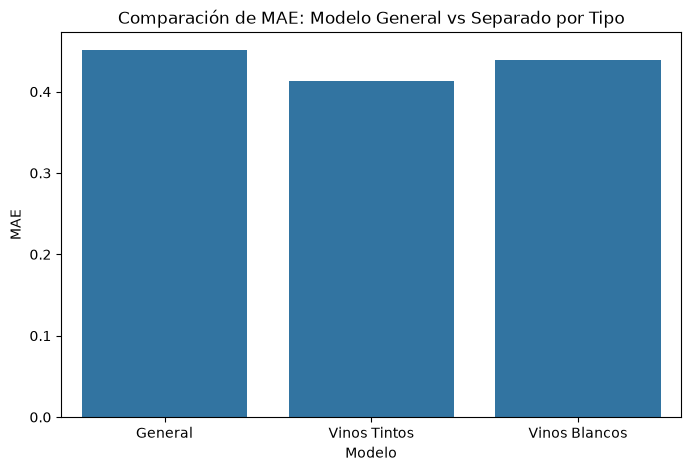

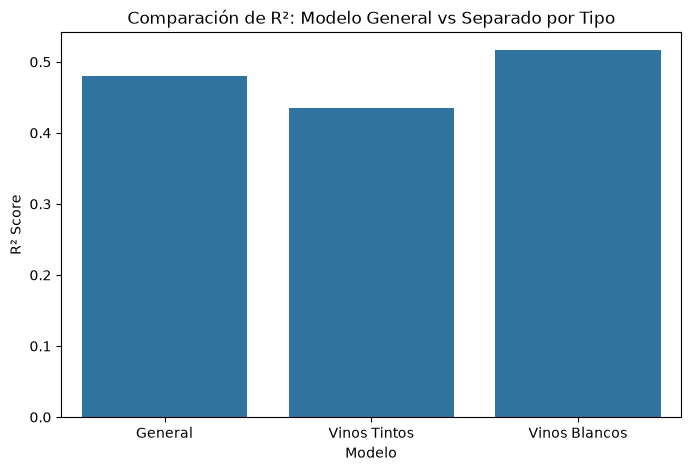

In [35]:
# ==========================================================
# GRÁFICOS DE BARRAS: COMPARACIÓN DEL MODELO GENERAL VS
# REGRESIÓN SEPARADA POR TIPO DE VINO
# ==========================================================
# En estos gráficos comparamos el rendimiento del mejor
# modelo general con los modelos entrenados por separado
# para vinos tintos y vinos blancos.
#
# Métricas comparadas:
# - MAE  -> menor es mejor
# - R²   -> mayor es mejor

# ----------------------------------------------------------
# Crear dataframe auxiliar para graficar
# ----------------------------------------------------------

results_split_plot = pd.DataFrame({
    'Modelo': [
        'General',
        'Vinos Tintos',
        'Vinos Blancos'
    ],
    'MAE': [
        mae_xgb_reg,
        mae_xgb_red,
        mae_xgb_white
    ],
    'R² Score': [
        r2_xgb_reg,
        r2_xgb_red,
        r2_xgb_white
    ]
})


# ----------------------------------------------------------
# Gráfico de barras para MAE
# ----------------------------------------------------------
# Este gráfico permite comparar el error promedio de los
# tres enfoques. Un valor más bajo indica mejor desempeño.

plt.figure(figsize=(8, 5))
sns.barplot(data=results_split_plot, x='Modelo', y='MAE')

plt.title('Comparación de MAE: Modelo General vs Separado por Tipo')
plt.ylabel('MAE')
plt.xlabel('Modelo')
plt.show()


# ----------------------------------------------------------
# Gráfico de barras para R² Score
# ----------------------------------------------------------
# Este gráfico permite comparar qué tan bien explica cada
# modelo la variabilidad de la calidad del vino.
# Un valor más alto indica mejor desempeño.

plt.figure(figsize=(8, 5))
sns.barplot(data=results_split_plot, x='Modelo', y='R² Score')

plt.title('Comparación de R²: Modelo General vs Separado por Tipo')
plt.ylabel('R² Score')
plt.xlabel('Modelo')
plt.show()

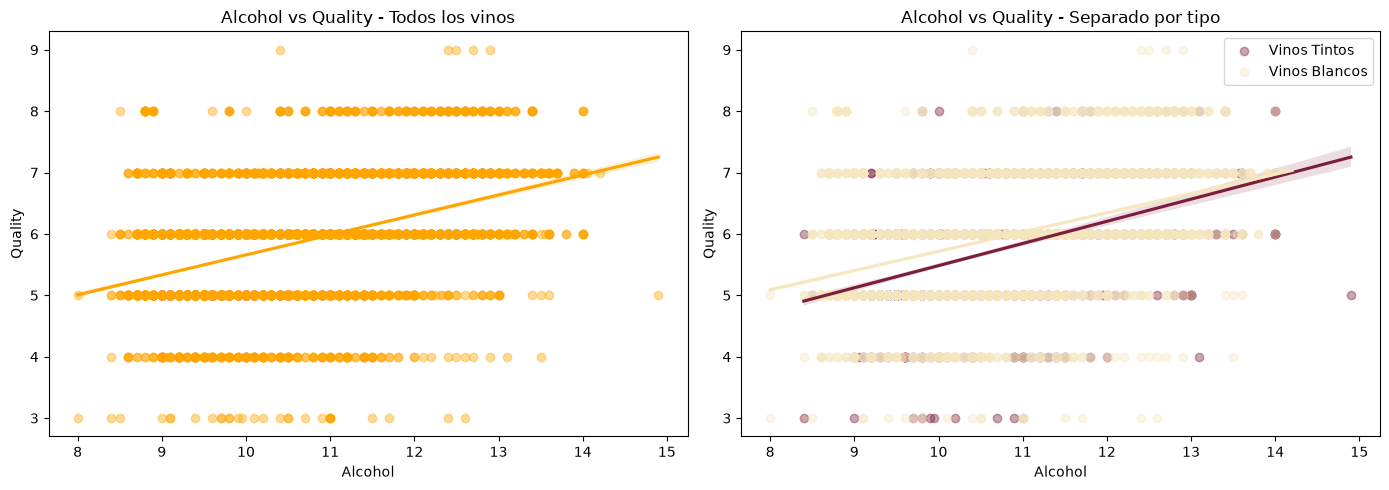

In [36]:
# ==========================================================
# REGRESIÓN LINEAL VISUAL: ALCOHOL VS QUALITY
# COMPARACIÓN ENTRE MODELO GENERAL Y SEPARADO POR TIPO
# ==========================================================
# En estos gráficos mostramos la relación entre alcohol
# y quality:
# - a la izquierda: todos los vinos juntos
# - a la derecha: separados por tipo de vino

# ----------------------------------------------------------
# Crear figura con dos gráficos
# ----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ----------------------------------------------------------
# Gráfico 1: todos los vinos juntos
# ----------------------------------------------------------

sns.regplot(
    data=df,
    x='alcohol',
    y='quality',
    scatter_kws={'alpha': 0.4, 'color': 'orange'},
    line_kws={'color': 'orange'},
    ax=axes[0]
)

axes[0].set_title('Alcohol vs Quality - Todos los vinos')
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Quality')


# ----------------------------------------------------------
# Gráfico 2: separados por tipo de vino
# ----------------------------------------------------------

sns.regplot(
    data=df[df['type'] == 'red'],
    x='alcohol',
    y='quality',
    scatter_kws={'alpha': 0.4, 'color': '#7B1E3A'},
    line_kws={'color': '#7B1E3A'},
    ax=axes[1],
    label='Vinos Tintos'
)

sns.regplot(
    data=df[df['type'] == 'white'],
    x='alcohol',
    y='quality',
    scatter_kws={'alpha': 0.4, 'color': '#F6E7C1'},
    line_kws={'color': '#F6E7C1'},
    ax=axes[1],
    label='Vinos Blancos'
)

axes[1].set_title('Alcohol vs Quality - Separado por tipo')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Quality')
axes[1].legend()


# ----------------------------------------------------------
# Ajustar diseño y mostrar gráfico
# ----------------------------------------------------------

plt.tight_layout()
plt.show()

#Conclusión
Al separar la tarea de regresión por tipo de vino, se observó que el impacto no fue uniforme. En vinos blancos, el modelo mejoró tanto en MAE como en R² respecto del modelo general, lo que indica que trabajar con un subconjunto más homogéneo permitió capturar mejor la relación entre las variables fisicoquímicas y la calidad. En vinos tintos, en cambio, si bien el MAE disminuyó, el R² fue menor que en el modelo general, por lo que la mejora no fue completa. En consecuencia, esta estrategia parece especialmente útil para vinos blancos, pero no garantiza una mejora global en todos los casos.

##Agregar type como feature en la regresión

In [37]:
# ==========================================================
# REGRESIÓN GENERAL INCLUYENDO 'type' COMO FEATURE
# ==========================================================
# En esta versión no separamos el dataset por tipo de vino.
# En cambio, agregamos la columna 'type' como variable
# predictora para que el modelo pueda usar esa información.

# ----------------------------------------------------------
# Copiar el dataset original
# ----------------------------------------------------------

df_reg_type = df.copy()


# ----------------------------------------------------------
# Codificar la variable 'type'
# ----------------------------------------------------------
# Convertimos:
# red   -> 0
# white -> 1

df_reg_type['type'] = df_reg_type['type'].map({'red': 0, 'white': 1})


# ----------------------------------------------------------
# Definir features y target
# ----------------------------------------------------------
# Ahora sí incluimos 'type' dentro de las features
# y dejamos 'quality' como variable objetivo.

X_reg_type = df_reg_type.drop('quality', axis=1)
y_reg_type = df_reg_type['quality']


# ----------------------------------------------------------
# División en Train y Test
# ----------------------------------------------------------

X_train_reg_type, X_test_reg_type, y_train_reg_type, y_test_reg_type = train_test_split(
    X_reg_type,
    y_reg_type,
    test_size=0.25,
    random_state=42
)


# ----------------------------------------------------------
# Escalamiento de datos
# ----------------------------------------------------------

scaler_reg_type = StandardScaler()

X_train_reg_type_scaled = scaler_reg_type.fit_transform(X_train_reg_type)
X_test_reg_type_scaled = scaler_reg_type.transform(X_test_reg_type)

In [38]:
# ==========================================================
# XGBOOST REGRESSOR OPTIMIZADO - REGRESIÓN GENERAL CON TYPE
# ==========================================================
# Entrenamos un modelo XGBoost Regressor usando todas las
# variables fisicoquímicas y además la variable 'type'.

print("\n--- Entrenando XGBoost Regressor optimizado con 'type' como feature ---")

# ----------------------------------------------------------
# Definir el modelo base
# ----------------------------------------------------------

xgb_reg_type = XGBRegressor(
    random_state=42,
    eval_metric='rmse'
)


# ----------------------------------------------------------
# Definir la grilla de hiperparámetros
# ----------------------------------------------------------

param_grid_xgb_type = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}


# ----------------------------------------------------------
# Configurar GridSearchCV
# ----------------------------------------------------------

grid_xgb_type = GridSearchCV(
    estimator=xgb_reg_type,
    param_grid=param_grid_xgb_type,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)


# ----------------------------------------------------------
# Entrenar GridSearchCV
# ----------------------------------------------------------

grid_xgb_type.fit(X_train_reg_type_scaled, y_train_reg_type)


# ----------------------------------------------------------
# Mostrar mejores hiperparámetros encontrados
# ----------------------------------------------------------

print("Mejores hiperparámetros para XGBoost Regressor con 'type' como feature:")
print(f"n_estimators = {grid_xgb_type.best_params_['n_estimators']}")
print(f"max_depth = {grid_xgb_type.best_params_['max_depth']}")
print(f"learning_rate = {grid_xgb_type.best_params_['learning_rate']}")


# ----------------------------------------------------------
# Predicción con el mejor modelo encontrado
# ----------------------------------------------------------

best_xgb_type = grid_xgb_type.best_estimator_
y_pred_xgb_type = best_xgb_type.predict(X_test_reg_type_scaled)


# ----------------------------------------------------------
# Evaluación del modelo
# ----------------------------------------------------------

mae_xgb_type = mean_absolute_error(y_test_reg_type, y_pred_xgb_type)
r2_xgb_type = r2_score(y_test_reg_type, y_pred_xgb_type)

print(f"MAE XGBoost Regressor con 'type' como feature: {mae_xgb_type:.4f}")
print(f"R² Score XGBoost Regressor con 'type' como feature: {r2_xgb_type:.4f}")


--- Entrenando XGBoost Regressor optimizado con 'type' como feature ---
Mejores hiperparámetros para XGBoost Regressor con 'type' como feature:
n_estimators = 200
max_depth = 7
learning_rate = 0.1
MAE XGBoost Regressor con 'type' como feature: 0.4534
R² Score XGBoost Regressor con 'type' como feature: 0.4881


In [39]:
# ==========================================================
# TABLA COMPARATIVA FINAL DE ESTRATEGIAS DE REGRESIÓN
# ==========================================================
# En esta tabla comparamos distintas estrategias para
# predecir quality:
# - modelo general
# - modelo separado por tintos
# - modelo separado por blancos
# - modelo general incluyendo 'type' como feature

results_reg_strategies = pd.DataFrame({
    'Modelo': [
        'XGBoost Regressor optimizado - General',
        'XGBoost Regressor optimizado - Vinos Tintos',
        'XGBoost Regressor optimizado - Vinos Blancos',
        "XGBoost Regressor optimizado - General con 'type'"
    ],
    'MAE': [
        mae_xgb_reg,
        mae_xgb_red,
        mae_xgb_white,
        mae_xgb_type
    ],
    'R² Score': [
        r2_xgb_reg,
        r2_xgb_red,
        r2_xgb_white,
        r2_xgb_type
    ]
})


# ----------------------------------------------------------
# Redondear métricas para mejor visualización
# ----------------------------------------------------------

results_reg_strategies['MAE'] = results_reg_strategies['MAE'].round(4)
results_reg_strategies['R² Score'] = results_reg_strategies['R² Score'].round(4)


# ----------------------------------------------------------
# Mostrar tabla final
# ----------------------------------------------------------

display(results_reg_strategies)

,Modelo,MAE,R² Score
0,XGBoost Regressor optimizado - General,0.4507,0.4805
1,XGBoost Regressor optimizado - Vinos Tintos,0.4132,0.4350
2,XGBoost Regressor optimizado - Vinos Blancos,0.4395,0.5161
3,XGBoost Regressor optimizado - General con 'type',0.4534,0.4881


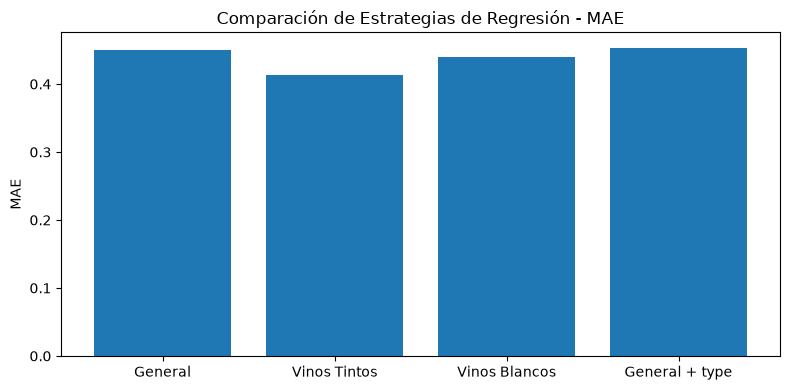

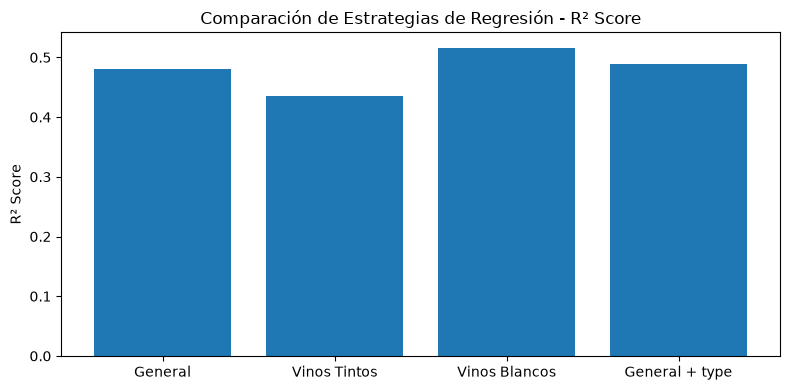

In [40]:
# ==========================================================
# GRÁFICO DE BARRAS: COMPARACIÓN DE ESTRATEGIAS DE REGRESIÓN
# ==========================================================
# En este gráfico comparamos distintas estrategias para
# predecir quality:
# - modelo general
# - modelo separado por vinos tintos
# - modelo separado por vinos blancos
# - modelo general incluyendo 'type' como feature

# ----------------------------------------------------------
# Crear etiquetas más cortas para el eje X
# ----------------------------------------------------------

labels_modelos = [
    'General',
    'Vinos Tintos',
    'Vinos Blancos',
    "General + type"
]


# ----------------------------------------------------------
# Crear figura para MAE
# ----------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.bar(labels_modelos, results_reg_strategies['MAE'])

plt.title('Comparación de Estrategias de Regresión - MAE')
plt.ylabel('MAE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# Crear figura para R² Score
# ----------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.bar(labels_modelos, results_reg_strategies['R² Score'])

plt.title('Comparación de Estrategias de Regresión - R² Score')
plt.ylabel('R² Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Conclusión

Al incorporar la variable `type` como feature dentro del modelo general de regresión, no se observaron mejoras significativas respecto del modelo general original. Si bien el **MAE** disminuyó levemente, pasando de **0.4515** a **0.4484**, el **R²** también descendió de **0.4865** a **0.4836**, lo que indica que la capacidad explicativa del modelo no mejoró. En comparación con la estrategia de separar por tipo de vino, los resultados muestran que incluir `type` como variable predictora no fue suficiente para capturar mejor las diferencias entre vinos tintos y blancos. En consecuencia, esta alternativa no parece aportar una ventaja clara frente al modelo general, y la separación por tipo sigue siendo más útil, especialmente en el caso de los vinos blancos.


##Quality como clasificacion
Como alternativa final, sería reformular la predicción de quality como un problema de clasificación en lugar de regresión. Esto se justifica porque la variable calidad toma pocos valores enteros y se concentra principalmente en categorías intermedias, lo que dificulta su modelado como una variable continua. En ese contexto, agrupar los niveles de calidad en clases podría permitir a los modelos capturar mejor los patrones del dataset.

baja: 3, 4, 5

media: 6

alta: 7, 8, 9

In [41]:
# ==========================================================
# Quality COMO PROBLEMA DE CLASIFICACIÓN
# ==========================================================
# En esta sección transformamos la variable quality en una
# variable categórica de 3 clases:
# - 0 -> calidad baja   (3, 4, 5)
# - 1 -> calidad media  (6)
# - 2 -> calidad alta   (7, 8, 9)

# ----------------------------------------------------------
# Crear nueva variable objetivo multiclase
# ----------------------------------------------------------

df_quality_clf = df.copy()

def map_quality_class(q):
    if q in [3, 4, 5]:
        return 0
    elif q == 6:
        return 1
    else:
        return 2

df_quality_clf['quality_class'] = df_quality_clf['quality'].apply(map_quality_class)


# ----------------------------------------------------------
# Definir features y target
# ----------------------------------------------------------

X_quality_clf = df_quality_clf.drop(['quality', 'quality_class'], axis=1)
y_quality_clf = df_quality_clf['quality_class']


# ----------------------------------------------------------
# Codificar la variable 'type'
# ----------------------------------------------------------

X_quality_clf['type'] = X_quality_clf['type'].map({'red': 0, 'white': 1})


# ----------------------------------------------------------
# División en Train y Test
# ----------------------------------------------------------

X_train_quality, X_test_quality, y_train_quality, y_test_quality = train_test_split(
    X_quality_clf,
    y_quality_clf,
    test_size=0.25,
    random_state=42,
    stratify=y_quality_clf
)


# ----------------------------------------------------------
# Escalamiento de datos
# ----------------------------------------------------------

scaler_quality = StandardScaler()

X_train_quality_scaled = scaler_quality.fit_transform(X_train_quality)
X_test_quality_scaled = scaler_quality.transform(X_test_quality)

##Modelo Regresión Logística

In [42]:
# ==========================================================
# MODELO 1: REGRESIÓN LOGÍSTICA PARA QUALITY CLASIFICADA
# ==========================================================

print("--- Entrenando Regresión Logística para quality clasificada ---")

log_reg_quality = LogisticRegression(random_state=42, max_iter=1000)

log_reg_quality.fit(X_train_quality_scaled, y_train_quality)

y_pred_log_quality = log_reg_quality.predict(X_test_quality_scaled)

print(classification_report(
    y_test_quality,
    y_pred_log_quality,
    target_names=['baja', 'media', 'alta']
))

--- Entrenando Regresión Logística para quality clasificada ---
              precision    recall  f1-score   support

        baja       0.63      0.61      0.62       596
       media       0.52      0.64      0.58       709
        alta       0.61      0.34      0.44       320

    accuracy                           0.57      1625
   macro avg       0.59      0.53      0.55      1625
weighted avg       0.58      0.57      0.57      1625



##Modelo Random Forest + GridSearchCV

In [43]:
# ==========================================================
# MODELO 2: RANDOM FOREST + GRIDSEARCHCV PARA QUALITY CLASIFICADA
# ==========================================================

print("\n--- Entrenando Random Forest para quality clasificada ---")

rf_quality = RandomForestClassifier(random_state=42)

param_grid_rf_quality = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf_quality = GridSearchCV(
    estimator=rf_quality,
    param_grid=param_grid_rf_quality,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf_quality.fit(X_train_quality_scaled, y_train_quality)

print("Mejores hiperparámetros para Random Forest:")
print(f"n_estimators = {grid_rf_quality.best_params_['n_estimators']}")
print(f"max_depth = {grid_rf_quality.best_params_['max_depth']}")
print(f"min_samples_split = {grid_rf_quality.best_params_['min_samples_split']}")

best_rf_quality = grid_rf_quality.best_estimator_
y_pred_rf_quality = best_rf_quality.predict(X_test_quality_scaled)

print("\nClassification Report - Random Forest:")
print(classification_report(
    y_test_quality,
    y_pred_rf_quality,
    target_names=['baja', 'media', 'alta']
))


--- Entrenando Random Forest para quality clasificada ---
Mejores hiperparámetros para Random Forest:
n_estimators = 100
max_depth = 20
min_samples_split = 5

Classification Report - Random Forest:
              precision    recall  f1-score   support

        baja       0.77      0.75      0.76       596
       media       0.67      0.72      0.70       709
        alta       0.72      0.63      0.67       320

    accuracy                           0.72      1625
   macro avg       0.72      0.70      0.71      1625
weighted avg       0.72      0.72      0.72      1625



Modelo XGBoost + GridSearchCV

In [44]:
# ==========================================================
# MODELO 3: XGBOOST + GRIDSEARCHCV PARA QUALITY CLASIFICADA
# ==========================================================

print("\n--- Entrenando XGBoost para quality clasificada ---")

xgb_quality = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

param_grid_xgb_quality = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

grid_xgb_quality = GridSearchCV(
    estimator=xgb_quality,
    param_grid=param_grid_xgb_quality,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb_quality.fit(X_train_quality_scaled, y_train_quality)

print("Mejores hiperparámetros para XGBoost:")
print(f"n_estimators = {grid_xgb_quality.best_params_['n_estimators']}")
print(f"max_depth = {grid_xgb_quality.best_params_['max_depth']}")
print(f"learning_rate = {grid_xgb_quality.best_params_['learning_rate']}")

best_xgb_quality = grid_xgb_quality.best_estimator_
y_pred_xgb_quality = best_xgb_quality.predict(X_test_quality_scaled)

print("\nClassification Report - XGBoost:")
print(classification_report(
    y_test_quality,
    y_pred_xgb_quality,
    target_names=['baja', 'media', 'alta']
))


--- Entrenando XGBoost para quality clasificada ---
Mejores hiperparámetros para XGBoost:
n_estimators = 200
max_depth = 7
learning_rate = 0.1

Classification Report - XGBoost:
              precision    recall  f1-score   support

        baja       0.75      0.73      0.74       596
       media       0.66      0.68      0.67       709
        alta       0.68      0.65      0.67       320

    accuracy                           0.69      1625
   macro avg       0.70      0.69      0.69      1625
weighted avg       0.70      0.69      0.69      1625



##Tabla de resultados

In [45]:
# ==========================================================
# MODELO 3: XGBOOST + GRIDSEARCHCV PARA QUALITY CLASIFICADA
# ==========================================================

print("\n--- Entrenando XGBoost para quality clasificada ---")

xgb_quality = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

param_grid_xgb_quality = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

grid_xgb_quality = GridSearchCV(
    estimator=xgb_quality,
    param_grid=param_grid_xgb_quality,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb_quality.fit(X_train_quality_scaled, y_train_quality)

print("Mejores hiperparámetros para XGBoost:")
print(f"n_estimators = {grid_xgb_quality.best_params_['n_estimators']}")
print(f"max_depth = {grid_xgb_quality.best_params_['max_depth']}")
print(f"learning_rate = {grid_xgb_quality.best_params_['learning_rate']}")

best_xgb_quality = grid_xgb_quality.best_estimator_
y_pred_xgb_quality = best_xgb_quality.predict(X_test_quality_scaled)

print("\nClassification Report - XGBoost:")
print(classification_report(
    y_test_quality,
    y_pred_xgb_quality,
    target_names=['baja', 'media', 'alta']
))


--- Entrenando XGBoost para quality clasificada ---
Mejores hiperparámetros para XGBoost:
n_estimators = 200
max_depth = 7
learning_rate = 0.1

Classification Report - XGBoost:
              precision    recall  f1-score   support

        baja       0.75      0.73      0.74       596
       media       0.66      0.68      0.67       709
        alta       0.68      0.65      0.67       320

    accuracy                           0.69      1625
   macro avg       0.70      0.69      0.69      1625
weighted avg       0.70      0.69      0.69      1625



In [46]:
# ==========================================================
# GRÁFICO DE BARRAS: COMPARACIÓN DE MODELOS PARA QUALITY
# ==========================================================
# En este gráfico comparamos Accuracy y F1-Score weighted avg
# de los modelos entrenados para quality como clasificación
# multiclase.

plt.figure(figsize=(10, 6))

# ----------------------------------------------------------
# Datos a graficar
# ----------------------------------------------------------

modelos = results_quality_clf['Modelo']
accuracy_vals = results_quality_clf['Accuracy']
f1_vals = results_quality_clf['F1-Score (weighted avg)']

x = np.arange(len(modelos))
width = 0.35


# ----------------------------------------------------------
# Barras de Accuracy y F1-Score
# ----------------------------------------------------------

plt.bar(x - width/2, accuracy_vals, width, label='Accuracy')
plt.bar(x + width/2, f1_vals, width, label='F1-Score (weighted avg)')


# ----------------------------------------------------------
# Configuración del gráfico
# ----------------------------------------------------------

plt.xticks(x, modelos, rotation=15)
plt.ylabel('Valor de la métrica')
plt.title('Comparación de modelos - Quality como clasificación multiclase')
plt.ylim(0, 1)
plt.legend()


# ----------------------------------------------------------
# Mostrar gráfico
# ----------------------------------------------------------

plt.show()

NameError: name 'results_quality_clf' is not defined

<Figure size 1000x600 with 0 Axes>

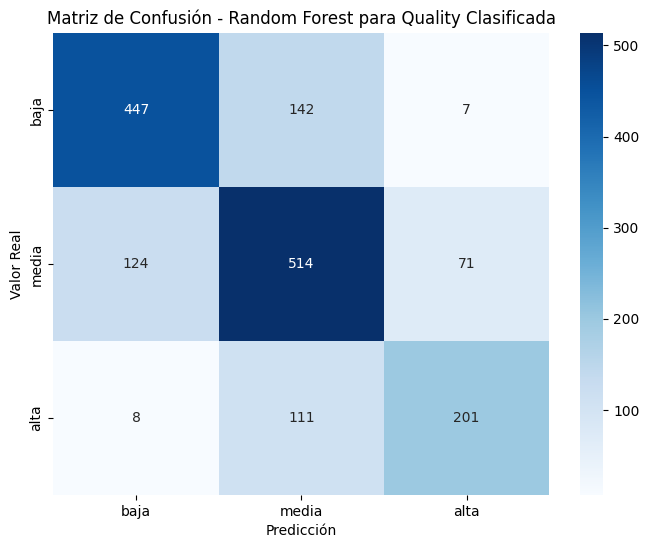

In [ ]:
# ==========================================================
# MATRIZ DE CONFUSIÓN - MEJOR MODELO DE QUALITY CLASIFICADA
# ==========================================================
# En esta sección mostramos la matriz de confusión del
# mejor modelo para la clasificación multiclase de quality.
# Según tus resultados, el mejor modelo fue Random Forest.

# ----------------------------------------------------------
# Calcular matriz de confusión
# ----------------------------------------------------------

cm_quality = confusion_matrix(y_test_quality, y_pred_rf_quality)


# ----------------------------------------------------------
# Visualizar matriz de confusión
# ----------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_quality,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['baja', 'media', 'alta'],
    yticklabels=['baja', 'media', 'alta']
)

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Random Forest para Quality Clasificada')

plt.show()

##Conclusíon
La reformulación de quality como problema de clasificación multiclase fue útil como experimento exploratorio, pero no produjo una mejora suficientemente clara respecto de la regresión. Si bien modelos como Random Forest y XGBoost alcanzaron resultados aceptables, las métricas obtenidas muestran que la separación entre las clases baja, media y alta sigue siendo limitada. Esto también se ve reflejado en los gráficos: el gráfico comparativo muestra mejoras moderadas entre modelos, mientras que la matriz de confusión evidencia confusiones importantes, especialmente entre las clases media y alta. En consecuencia, esta alternativa no parece ofrecer una ventaja fuerte como solución principal. En cambio, la estrategia de separar la regresión por tipo de vino resultó más consistente y defendible, especialmente en el caso de los vinos blancos.